# Setup

In [61]:
!pip install torchsummary
!pip install torchmetrics
!pip install git+https://github.com/fangwei123456/spikingjelly.git

  Cloning https://github.com/fangwei123456/spikingjelly.git to /tmp/pip-req-build-g4nxgpji
  Running command git clone --filter=blob:none --quiet https://github.com/fangwei123456/spikingjelly.git /tmp/pip-req-build-g4nxgpji
  Resolved https://github.com/fangwei123456/spikingjelly.git to commit e8dd4b522ff5a31c715e28d57cb3039bfeaea284
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [62]:
%matplotlib inline

# import
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torchvision
import numpy as np
from torchsummary import summary # Libraries for previewing neural network architectures
from spikingjelly.activation_based import neuron, encoding, functional, surrogate
from spikingjelly import visualizing
from matplotlib import pyplot as plt
import time

In [63]:
import os, re, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torch.optim import Optimizer, Adam, AdamW, SGD
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import timm
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import  ImageFolder
from collections import Counter
from torchvision.transforms import ToTensor
from torchmetrics import MeanMetric, Accuracy
from torchmetrics import ConfusionMatrix, Accuracy, Precision, Recall, F1Score


In [64]:
!python -m pip uninstall -y snn-bench


Found existing installation: snn_bench 0.1.85
Uninstalling snn_bench-0.1.85:
  Successfully uninstalled snn_bench-0.1.85


In [65]:
!pip install snn-bench --upgrade


  Using cached snn_bench-0.1.85-py3-none-any.whl.metadata (1.3 kB)
Using cached snn_bench-0.1.85-py3-none-any.whl (111 kB)


In [66]:
import snn_bench
from snn_bench import models, config

In [67]:
train_loader, val_loader, test_loader, meta = snn_bench.data.get_loaders(name='mnist')

In [68]:
numeric_labels = [x.split(' - ')[0] for x in train_loader.dataset.classes]
word_labels = [x.split(' - ')[1] for x in train_loader.dataset.classes]

In [69]:
train_loader.dataset.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [70]:
train_dataset, val_dataset, test_dataset = train_loader.dataset, val_loader.dataset, test_loader.dataset

In [71]:
NUM_CLASSES  = meta.num_classes
CLASS_NAMES  = numeric_labels
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes (10): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Train: 60000 | Val: 5000 | Test: 5000


In [72]:
cfg = config.Config(NUM_CLASSES, CLASS_NAMES, "./model_save/checkpoints")

# ANN

In [73]:
ann = models.ann.ANN(NUM_CLASSES)


In [74]:
from snn_bench.train import train_ann



  Training: ANN

  Training from scratch: no backbone(base_model) to freeze


  Epoch 1/30 | train_loss=2.0245 | train_acc=0.4973 | val=1.4566 | val_acc=0.746
{'epoch': 1, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 2.024531841278076, 'train_acc': 0.49732905626296997, 'val_loss': 1.456597924232483, 'val_acc': 0.746399998664856, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 2/30 | train_loss=1.2338 | train_acc=0.7532 | val=0.9917 | val_acc=0.856
{'epoch': 2, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 1.233812689781189, 'train_acc': 0.7532384991645813, 'val_loss': 0.9916759729385376, 'val_acc': 0.8561999797821045, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 3/30 | train_loss=0.9846 | train_acc=0.8397 | val=0.8649 | val_acc=0.899
{'epoch': 3, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.9846141338348389, 'train_acc': 0.8397101759910583, 'val_loss': 0.8648728728294373, 'val_acc': 0.899399995803833, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 4/30 | train_loss=0.8823 | train_acc=0.8809 | val=0.8004 | val_acc=0.916
{'epoch': 4, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.8822709918022156, 'train_acc': 0.8809428215026855, 'val_loss': 0.8003664612770081, 'val_acc': 0.9160000085830688, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


...

  Epoch 26/30 | train_loss=0.5905 | train_acc=0.9798 | val=0.5684 | val_acc=0.984
{'epoch': 26, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5905280113220215, 'train_acc': 0.9798009991645813, 'val_loss': 0.5683538317680359, 'val_acc': 0.9837999939918518, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 27/30 | train_loss=0.5879 | train_acc=0.9800 | val=0.5659 | val_acc=0.984
{'epoch': 27, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5878695249557495, 'train_acc': 0.9799679517745972, 'val_loss': 0.5659264922142029, 'val_acc': 0.9837999939918518, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 28/30 | train_loss=0.5855 | train_acc=0.9807 | val=0.5635 | val_acc=0.984
{'epoch': 28, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5854652523994446, 'train_acc': 0.9807191491127014, 'val_loss': 0.5635014772415161, 'val_acc': 0.9842000007629395, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 29/30 | train_loss=0.5833 | train_acc=0.9818 | val=0.5621 | val_acc=0.986
{'epoch': 29, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.5833088159561157, 'train_acc': 0.9817708134651184, 'val_loss': 0.5621349811553955, 'val_acc': 0.9864000082015991, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved


  Epoch 30/30 | train_loss=0.5811 | train_acc=0.9821 | val=0.5602 | val_acc=0.986
{'epoch': 30, 'model': 'ANN', 'model_name': 'ANN', 'train_loss': 0.581141471862793, 'train_acc': 0.9821214079856873, 'val_loss': 0.56020188331604, 'val_acc': 0.9861999750137329, 'optimizer': 'AdamW'}
  LR: 1.00e-05
  ✔ Val loss improved -> checkpoint saved
  ✔✔ Best checkpoint loaded: val_loss=0.5602


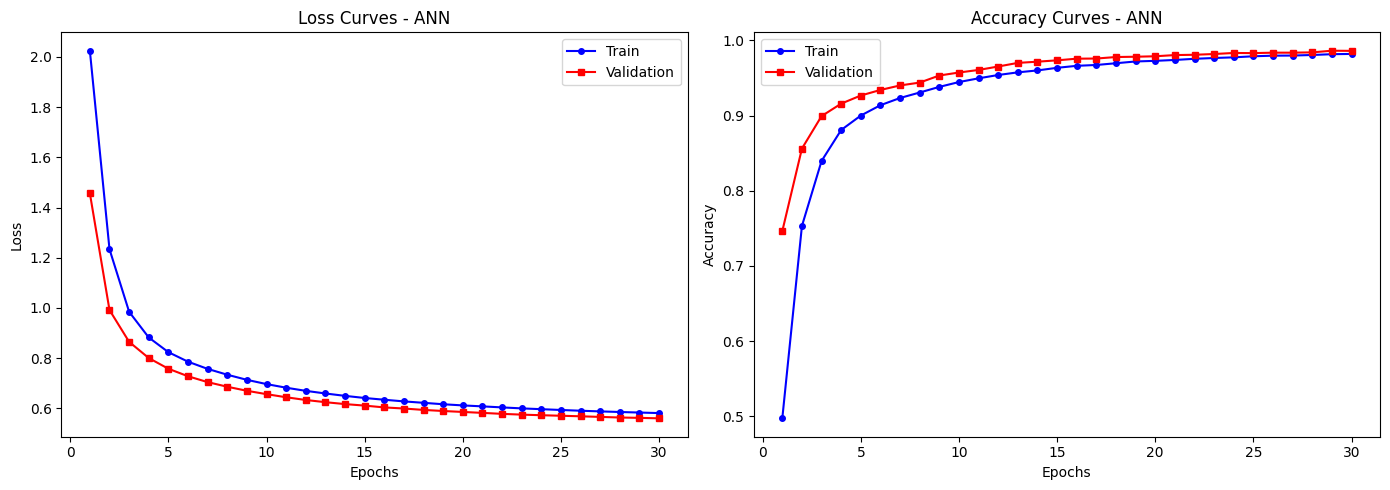


───────────────────────────────────────────────────────
  ANN
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0      0.972     0.993     0.982       451
           1      0.991     0.996     0.994       553
           2      0.970     0.978     0.974       495
           3      0.990     0.983     0.987       530
           4      0.990     0.976     0.983       501
           5      0.985     0.991     0.988       449
           6      0.987     0.976     0.981       460
           7      0.983     0.983     0.983       531
           8      0.982     0.986     0.984       508
           9      0.979     0.967     0.973       522

    accuracy                          0.983      5000
   macro avg      0.983     0.983     0.983      5000
weighted avg      0.983     0.983     0.983      5000

  Macro F1: 0.9829

  Confusion Matrix: tensor([[448,   0,   0,   0,   0,   1,   1,   1,   0,   0],
        [  0, 551,   2

In [75]:
#options = train_ann.TrainOptions.get_default()

ann_history_results, ann_evaluation_results, ann_results = train_ann.start_training_ann_loop(ann, train_loader, val_loader, test_loader, cfg)

In [76]:
from snn_bench.evaluate import eval_ann


  Confusion Matrix: ANN


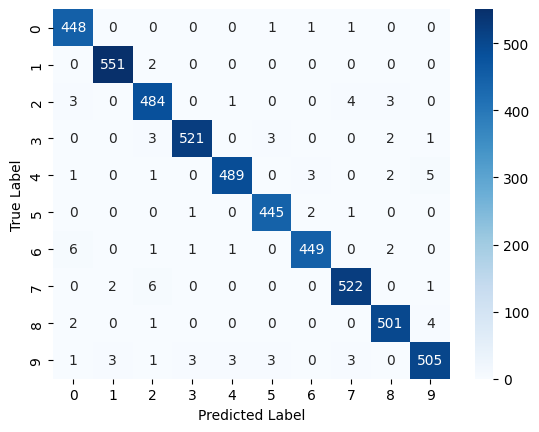

In [77]:
for model_name, er in ann_evaluation_results.items():
  print(f"\n{'='*60}")
  print(f"  Confusion Matrix: {model_name}")
  print(f"{'='*60}")
  eval_ann.plot_confusion_matrix(er, model_name, cfg)


True label: 3
Predicted label: 3


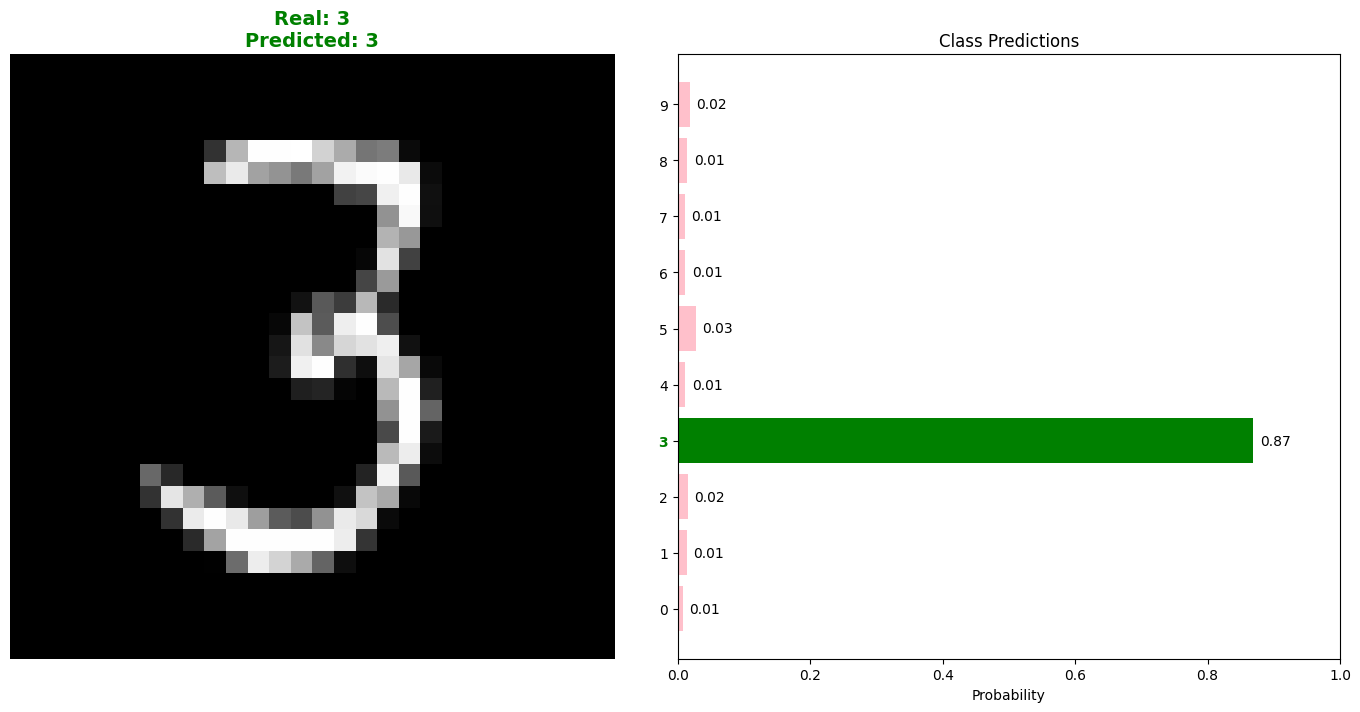

In [78]:
eval_ann.test_eval(ann, 4373, test_dataset, cfg)

# SNN

In [79]:
snn = models.snn.SNN()
snn.to(cfg.device)

SNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_1): Linear(in_features=784, out_features=10, bias=False)
  (lif_layer_1): LIFNode(
    v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
    (surrogate_function): ATan(alpha=2.0, spiking=True)
  )
)

In [80]:
from snn_bench.train import train_snn

In [81]:
snn_options = train_snn.TrainOptions.get_default_none()

loss_train_store, loss_cv_store, accuracy_rate_train_store, accuracy_rate_cv_store, epoch = train_snn.start_training_snn_loop(snn, train_loader, test_loader, cfg, snn_options)

----------- 0 round of training begins------------
loss train:  0.0322, accuracy rate train:  83.4850%, loss cv:  0.0223, accuracy rate cv:  89.6200%
----------- 1 round of training begins------------
loss train:  0.0204, accuracy rate train:  90.0950%, loss cv:  0.0198, accuracy rate cv:  90.4600%
----------- 2 round of training begins------------
loss train:  0.0187, accuracy rate train:  90.8983%, loss cv:  0.0186, accuracy rate cv:  90.6600%
----------- 3 round of training begins------------
loss train:  0.0178, accuracy rate train:  91.2383%, loss cv:  0.0182, accuracy rate cv:  91.1800%
----------- 4 round of training begins------------
loss train:  0.0173, accuracy rate train:  91.4167%, loss cv:  0.0179, accuracy rate cv:  90.9000%
-------------------------------Training Complete-------------------------------


In [82]:
from snn_bench.evaluate import eval_snn

---------Graph showing how the loss function changes over training epochs---------


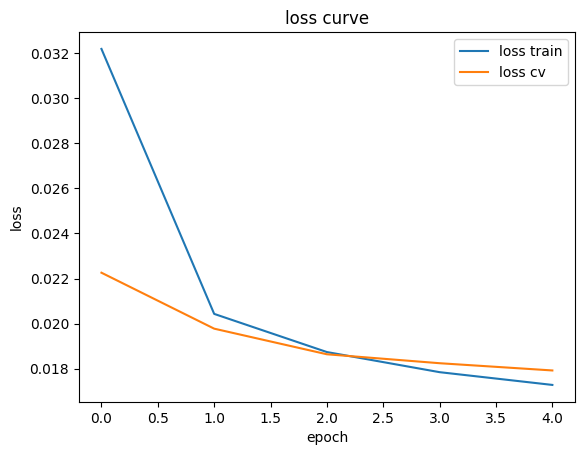

---------Graph showing how accuracy changes over training epochs---------


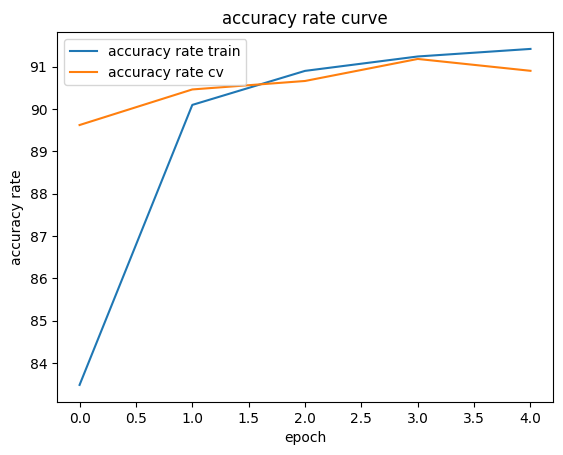

In [83]:
eval_snn.plot_loss_curves(epoch, loss_train_store, loss_cv_store, accuracy_rate_train_store, accuracy_rate_cv_store)

Original image
label: 7


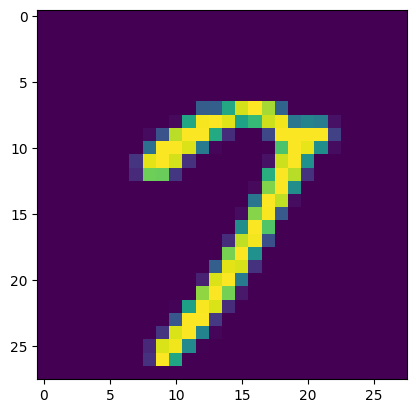

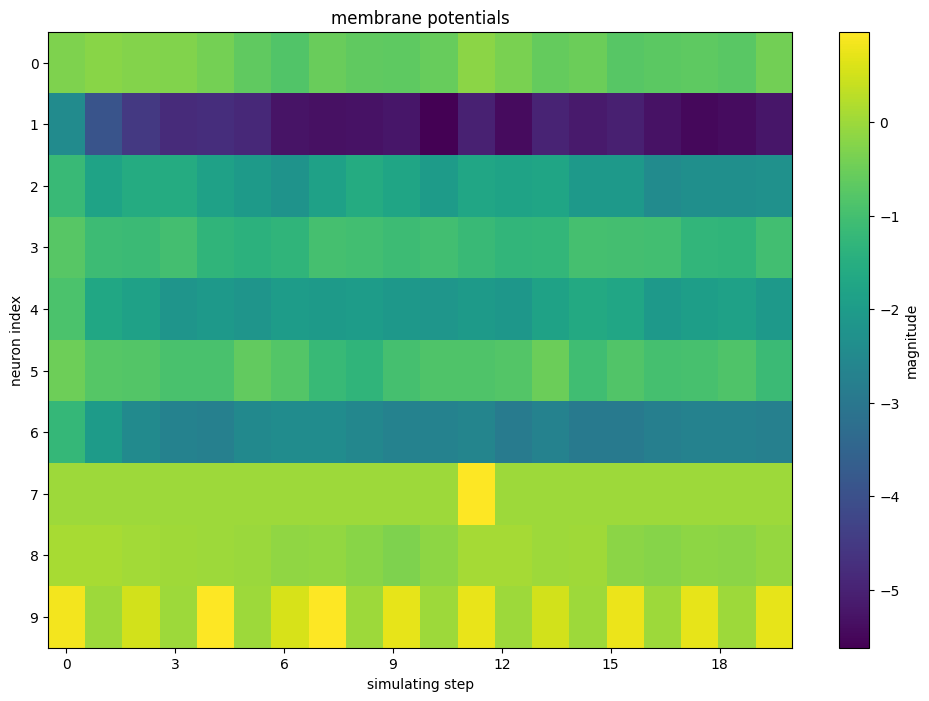

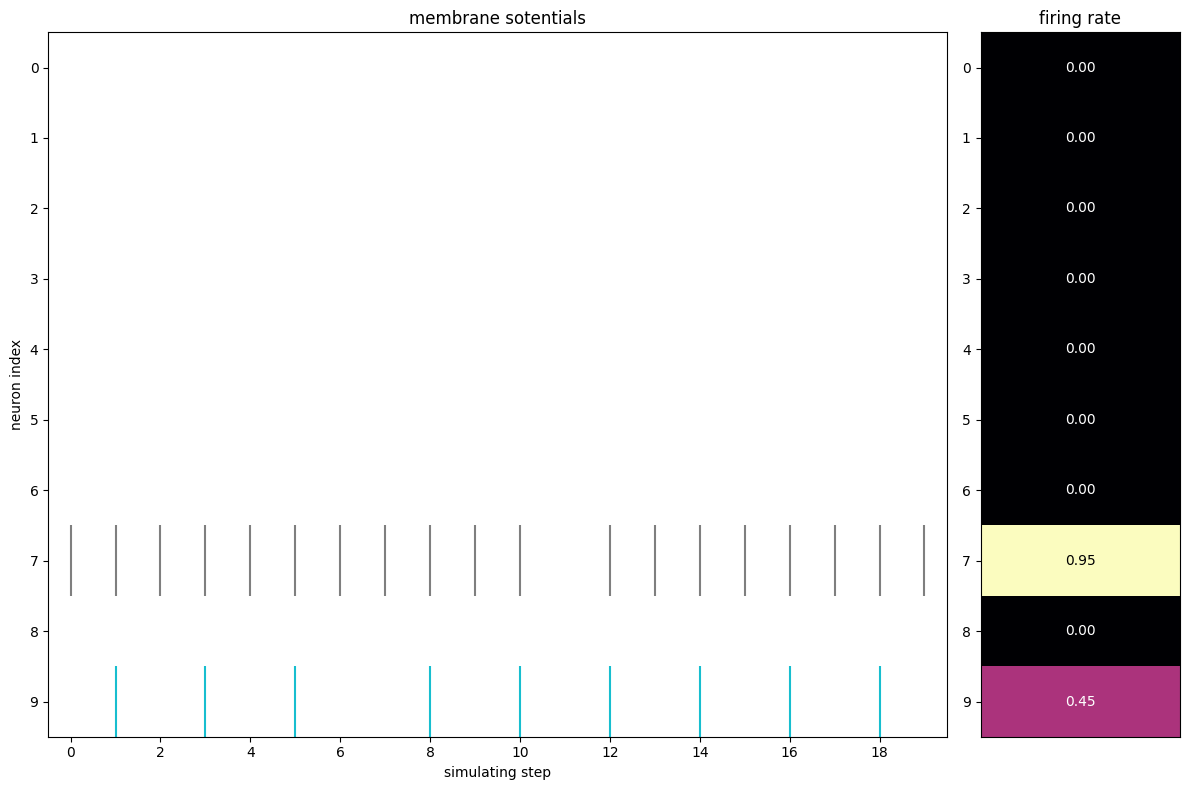

In [84]:
#For a more intuitive understanding, we can select a single image for prediction; by changing the index, we can choose different input images.

# Obtaining the membrane potential of the output layer neurons at this point is somewhat challenging and requires the use of the “hook” feature.

# Retrieve a single image for prediction

# Load the raw data
# Load a single image from the test set
# Save the data for plotting
snn.eval()
functional.reset_net(snn)
# Register a hook
output_layer = snn.lif_layer_1 # Output layer
output_layer.v_seq = []
output_layer.s_seq = []
def save_hook(m, x, y):
    m.v_seq.append(m.v.unsqueeze(0))
    m.s_seq.append(y.unsqueeze(0))

hook = output_layer.register_forward_hook(save_hook)

# Load a single image from the test set
index = 3373
input, label = test_dataset[index]
input = torchvision.transforms.ToPILImage()(input)
plt.imshow(input)
print('Original image')
print(f"label: {label}")
plt.show()

encoder = snn_options = train_snn.TrainOptions.get_default().encoder
T = 20
# Start making predictions with the neural network
snn.eval()

with torch.no_grad():
    img, label = test_dataset[index]
    img = img.unsqueeze(0).to(cfg.device)
    out_fr = 0.
    for t in range(T):
        encoded_img = encoder(img)
        out_fr += snn(encoded_img)
    out_spikes_counter_frequency = (out_fr / T).cpu().numpy()

    output_layer.v_seq = torch.cat(output_layer.v_seq)
    output_layer.s_seq = torch.cat(output_layer.s_seq)
    v_t_array = output_layer.v_seq.cpu().numpy().squeeze()  # v_t_array[i][j] represents the voltage value of neuron i at time j
    s_t_array = output_layer.s_seq.cpu().numpy().squeeze()  # s_t_array[i][j] represents the spike fired by neuron i at time j, which is either 0 or 1

    # Heatmap of membrane potentials and spike output results
    figsize = (12, 8)
    dpi = 100
    visualizing.plot_2d_heatmap(array=v_t_array, title='membrane potentials', xlabel='simulating step',
                                ylabel='neuron index', int_x_ticks=True, x_max=T, figsize=figsize, dpi=dpi)
    visualizing.plot_1d_spikes(spikes=s_t_array, title='membrane sotentials', xlabel='simulating step',
                            ylabel='neuron index', figsize=figsize, dpi=dpi)

    plt.show()

hook.remove()

In [85]:
snn = models.snn.DirectSNN(NUM_CLASSES)
snn.to(cfg.device)

DirectSNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (1): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=s)
    (4): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=False, step_mode=s, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1, step_mode=s)
    (1): Linear(in_features=3136, out_features=512, bias=False)
    (2): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=Fals

In [86]:
snn_options = train_snn.TrainOptions.get_default_none()

loss_train_store, loss_cv_store, accuracy_rate_train_store, accuracy_rate_cv_store, epoch = train_snn.start_training_snn_loop(snn, train_loader, test_loader, cfg, snn_options)

----------- 0 round of training begins------------
loss train:  0.0410, accuracy rate train:  66.3483%, loss cv:  0.0055, accuracy rate cv:  96.7000%
----------- 1 round of training begins------------
loss train:  0.0041, accuracy rate train:  97.5483%, loss cv:  0.0035, accuracy rate cv:  98.0600%
----------- 2 round of training begins------------
loss train:  0.0026, accuracy rate train:  98.3850%, loss cv:  0.0030, accuracy rate cv:  98.3400%
----------- 3 round of training begins------------
loss train:  0.0019, accuracy rate train:  98.8150%, loss cv:  0.0023, accuracy rate cv:  98.8000%
----------- 4 round of training begins------------
loss train:  0.0015, accuracy rate train:  99.0200%, loss cv:  0.0019, accuracy rate cv:  98.9200%
-------------------------------Training Complete-------------------------------


---------Graph showing how the loss function changes over training epochs---------


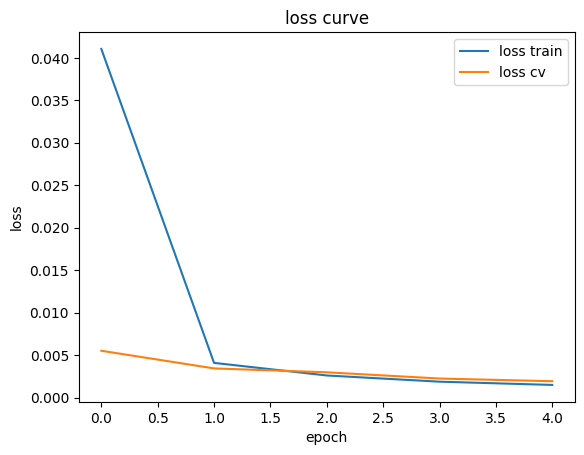

---------Graph showing how accuracy changes over training epochs---------


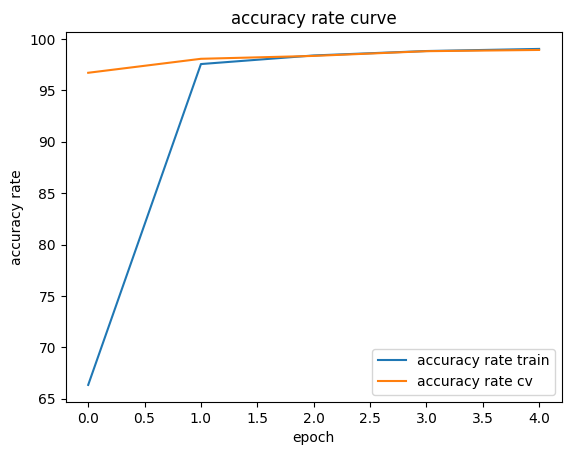

In [87]:
eval_snn.plot_loss_curves(epoch, loss_train_store, loss_cv_store, accuracy_rate_train_store, accuracy_rate_cv_store)

Original image
label: 8


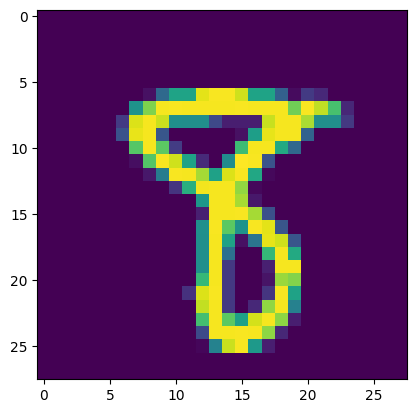

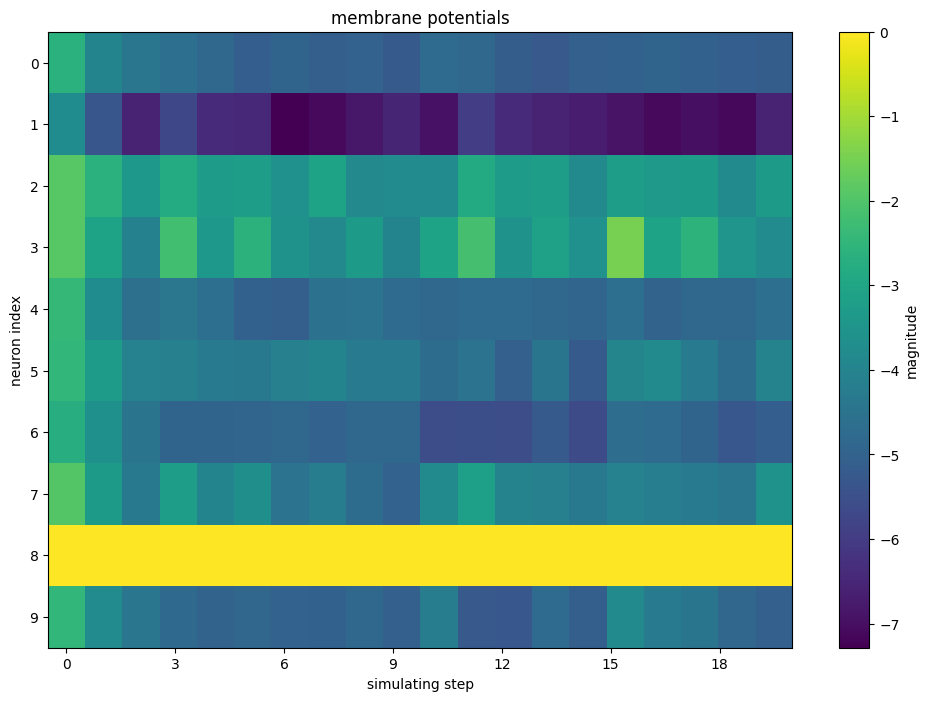

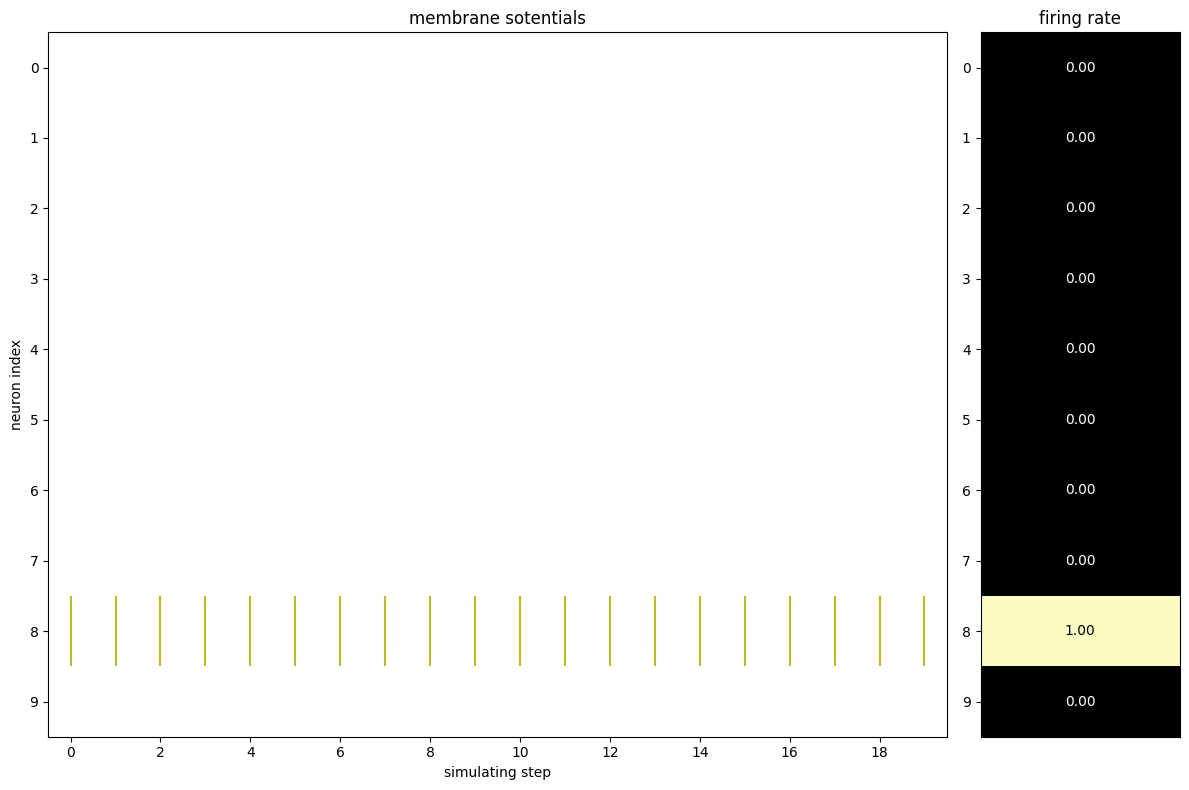

In [88]:
#For a more intuitive understanding, we can select a single image for prediction; by changing the index, we can choose different input images.

# Obtaining the membrane potential of the output layer neurons at this point is somewhat challenging and requires the use of the “hook” feature.

# Retrieve a single image for prediction

# Load the raw data
# Load a single image from the test set
# Save the data for plotting
snn.eval()
functional.reset_net(snn)
# Register a hook
output_layer = snn.classifier[6] # Output layer
output_layer.v_seq = []
output_layer.s_seq = []
def save_hook(m, x, y):
    m.v_seq.append(m.v.unsqueeze(0))
    m.s_seq.append(y.unsqueeze(0))

hook = output_layer.register_forward_hook(save_hook)

# Load a single image from the test set
index = 345
input, label = test_dataset[index]
input = torchvision.transforms.ToPILImage()(input)
plt.imshow(input)
print('Original image')
print(f"label: {label}")
plt.show()

encoder = snn_options = train_snn.TrainOptions.get_default().encoder
T = 20
# Start making predictions with the neural network
snn.eval()

with torch.no_grad():
    img, label = test_dataset[index]
    img = img.unsqueeze(0).to(cfg.device)
    out_fr = 0.
    for t in range(T):
        encoded_img = encoder(img)
        out_fr += snn(encoded_img)
    out_spikes_counter_frequency = (out_fr / T).cpu().numpy()

    output_layer.v_seq = torch.cat(output_layer.v_seq)
    output_layer.s_seq = torch.cat(output_layer.s_seq)
    v_t_array = output_layer.v_seq.cpu().numpy().squeeze()  # v_t_array[i][j] represents the voltage value of neuron i at time j
    s_t_array = output_layer.s_seq.cpu().numpy().squeeze()  # s_t_array[i][j] represents the spike fired by neuron i at time j, which is either 0 or 1

    # Heatmap of membrane potentials and spike output results
    figsize = (12, 8)
    dpi = 100
    visualizing.plot_2d_heatmap(array=v_t_array, title='membrane potentials', xlabel='simulating step',
                                ylabel='neuron index', int_x_ticks=True, x_max=T, figsize=figsize, dpi=dpi)
    visualizing.plot_1d_spikes(spikes=s_t_array, title='membrane sotentials', xlabel='simulating step',
                            ylabel='neuron index', figsize=figsize, dpi=dpi)

    plt.show()

hook.remove()

Original image
label: 0


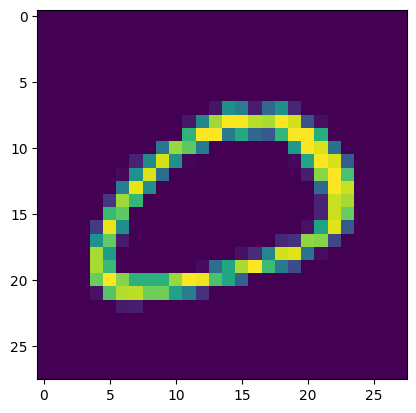

Unexpected err=RuntimeError('mat1 and mat2 shapes cannot be multiplied (64x49 and 3136x512)'), type(err)=<class 'RuntimeError'>


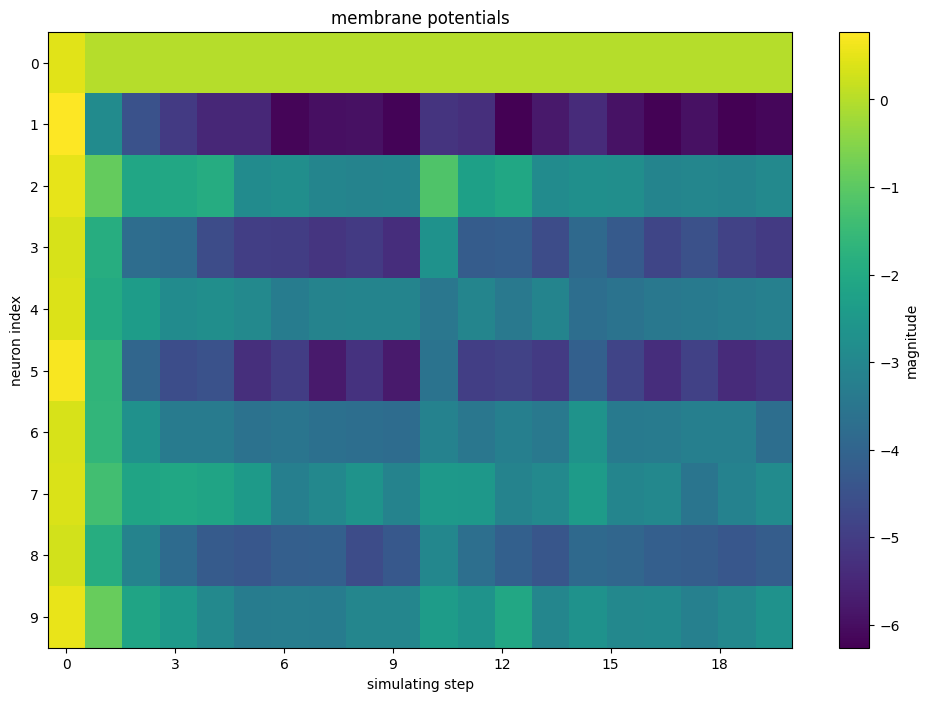

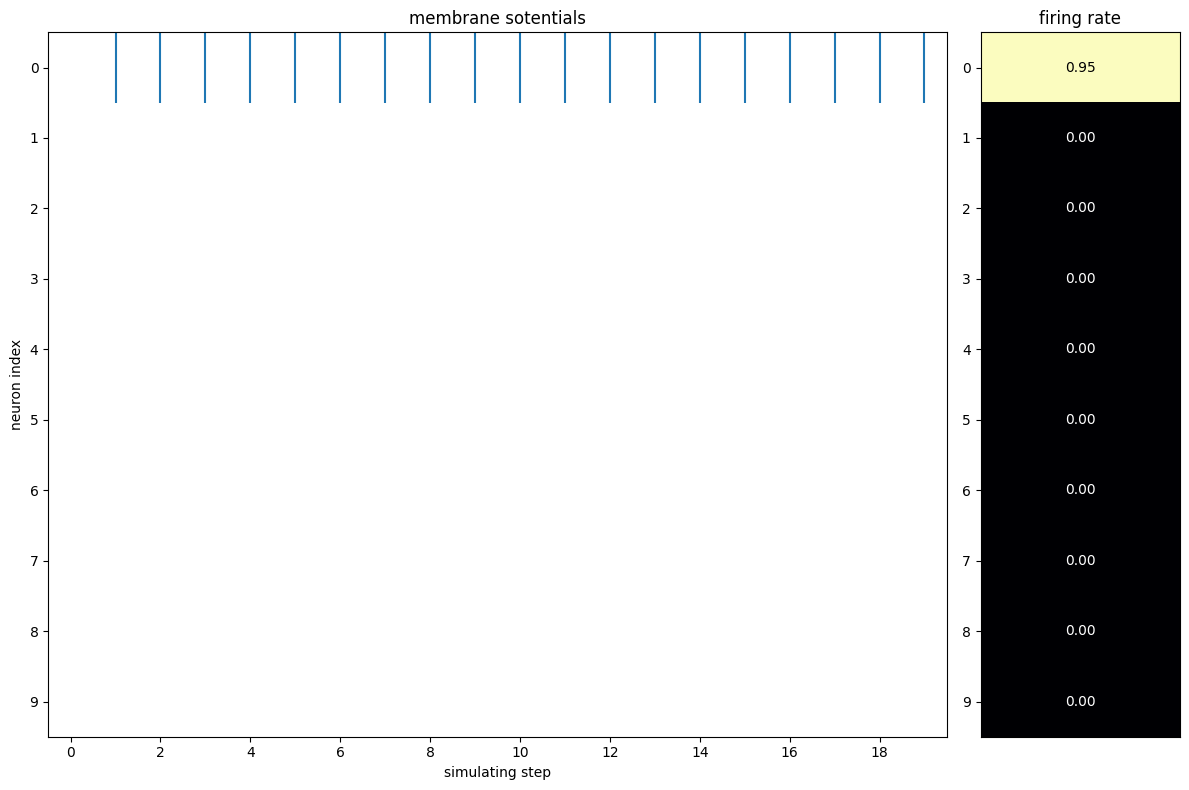

In [89]:
from spikingjelly.activation_based import neuron, encoding, functional, surrogate


eval_snn.plot_snn_module_spikes(snn, test_dataset, encoding.PoissonEncoder(), cfg, 798)

# ANN2SNN

In [90]:
from snn_bench.conversion import Converter
import snn_bench.conversion_mod.recipes as snn_bench_recipes

In [91]:
conv_snn_max = Converter.handle_rate_coded(ann, train_dataset, cfg)

100%|██████████| 469/469 [00:12<00:00, 36.47it/s]


In [92]:
conv_snn_max

GraphModule(
  (features): Module(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (spiking_0): Module(
      (scaler0): VoltageScaler(0.621029, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1): VoltageScaler(1.610231, step_mode=s)
    )
    (spiking_1): Module(
      (scaler0): VoltageScaler(0.442677, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1

In [93]:
conv_snn_99 =  Converter.handle_rate_coded(ann, train_dataset, cfg, mode="99.9%")

100%|██████████| 469/469 [00:13<00:00, 33.80it/s]


In [94]:
conv_snn_99

GraphModule(
  (features): Module(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), step_mode=s)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=s)
    (spiking_0): Module(
      (scaler0): VoltageScaler(0.750316, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1): VoltageScaler(1.332771, step_mode=s)
    )
    (spiking_1): Module(
      (scaler0): VoltageScaler(0.564107, step_mode=s)
      (if_node): IFNode(
        v_threshold=1.0, v_reset=None, detach_reset=False, step_mode=s, backend=torch
        (surrogate_function): Sigmoid(alpha=4.0, spiking=True)
      )
      (scaler1

In [95]:
conv_snn_balanced = Converter.handle_rate_coded_threshold_balanced(ann, train_dataset, cfg)

100%|██████████| 469/469 [00:13<00:00, 36.02it/s]


In [96]:
conv_snn_half =  Converter.handle_rate_coded(ann, train_dataset, cfg, mode=1.0/2)

100%|██████████| 469/469 [00:12<00:00, 36.47it/s]


In [97]:
from snn_bench.evaluate import eval_snn

In [98]:
curve_max  = eval_snn.accuracy_vs_T(conv_snn_max,  test_loader, T_max=64, device=cfg.device)
curve_99 = eval_snn.accuracy_vs_T(conv_snn_99, test_loader, T_max=64, device=cfg.device)
curve_half = eval_snn.accuracy_vs_T(conv_snn_half, test_loader, T_max=64, device=cfg.device)
curve_balanced = eval_snn.accuracy_vs_T(conv_snn_balanced, test_loader, T_max=64, device=cfg.device)
curve_base_snn = eval_snn.accuracy_vs_T(snn, test_loader, T_max=64, device=cfg.device)

In [99]:
ann_results['ANN'].accuracy

0.9829999804496765

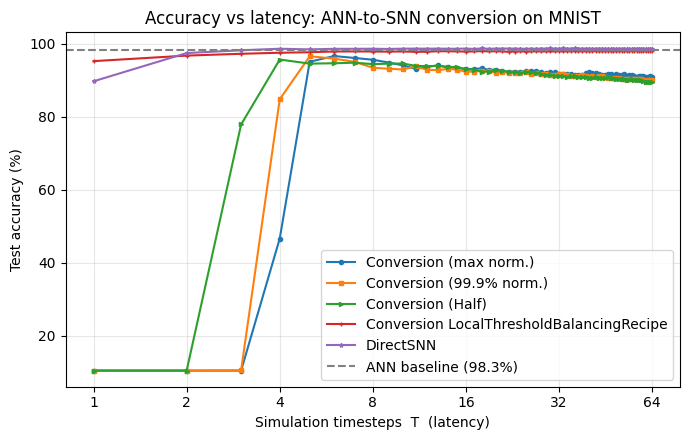

In [100]:
eval_snn.plot_accuracy_vs_T(ann_results['ANN'].accuracy, 64, [
    {"y": curve_max, "marker": "o", "ms": 3, "label": "Conversion (max norm.)"},
    {"y": curve_99,  "marker": "s", "ms": 3, "label": "Conversion (99.9% norm.)"},
    {"y": curve_half,  "marker": ">", "ms": 3, "label": "Conversion (Half)"},
    {"y": curve_balanced,  "marker": "+", "ms": 3, "label": "Conversion LocalThresholdBalancingRecipe"},
    {"y": curve_base_snn, "marker": "*", "ms": 3, "label": "DirectSNN"},
])

In [101]:
from snn_bench.conversion import eval_conv_snn

Original label: 7


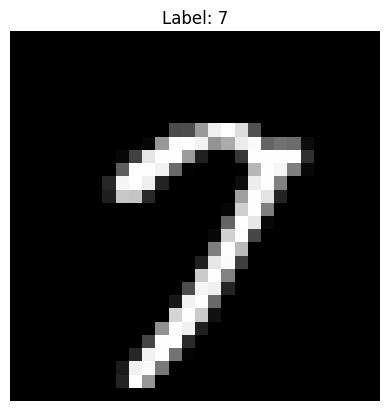

Predicted class (rate coding, T=16): 7


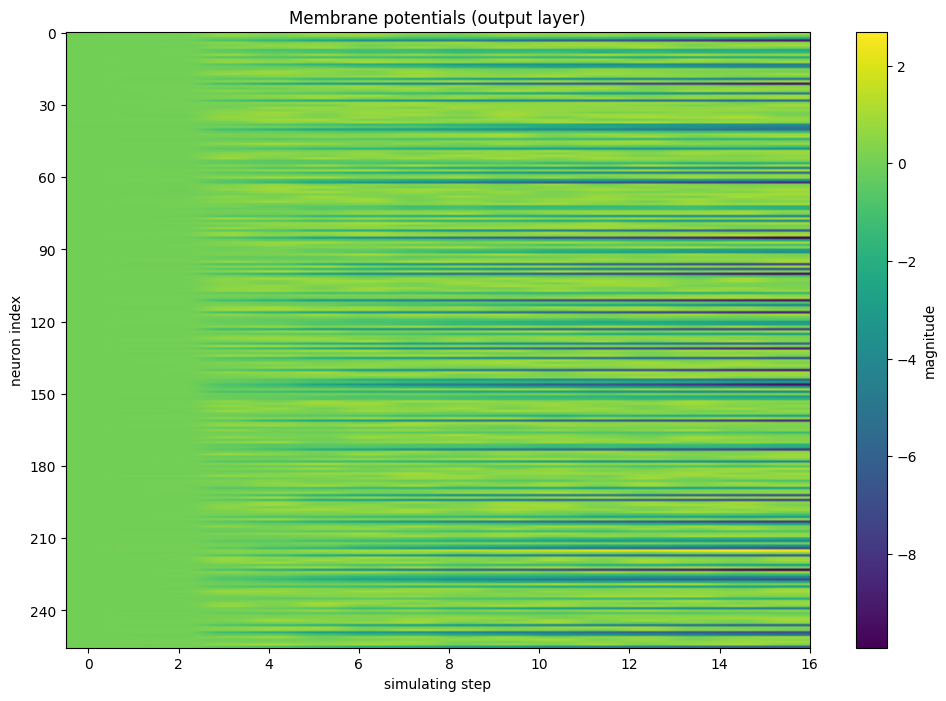

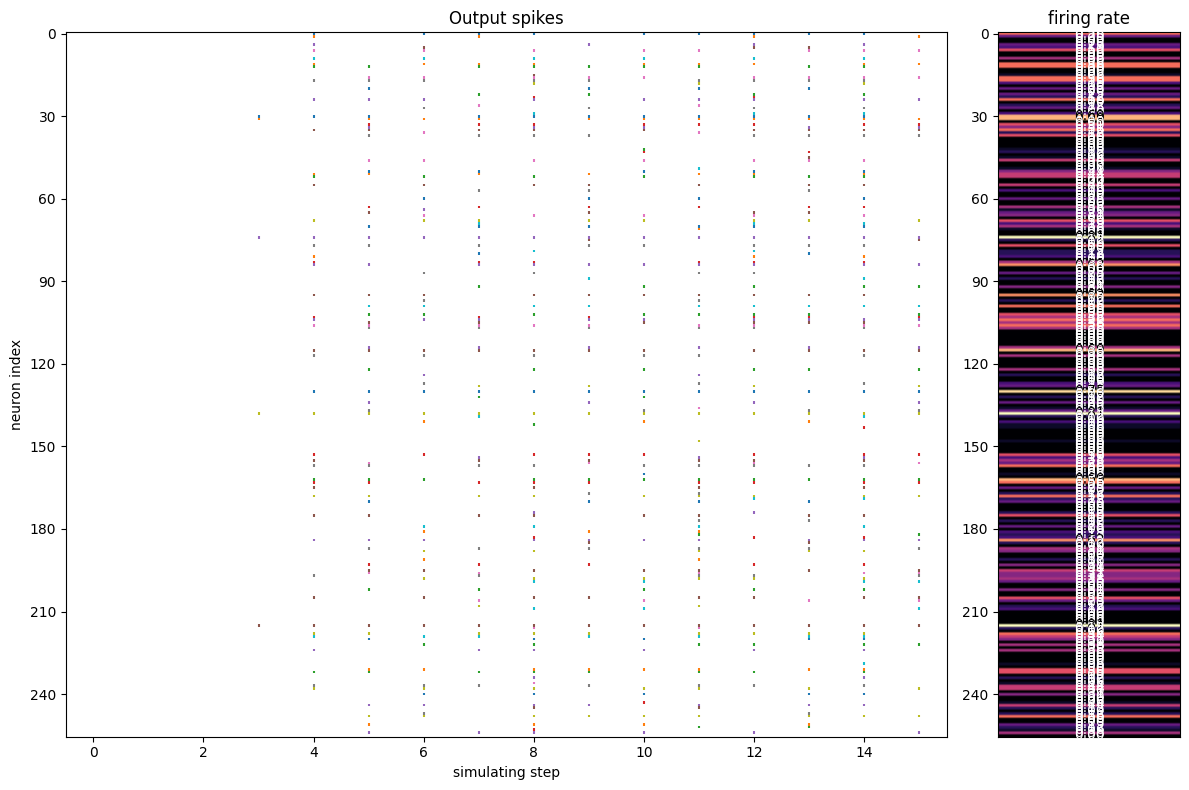

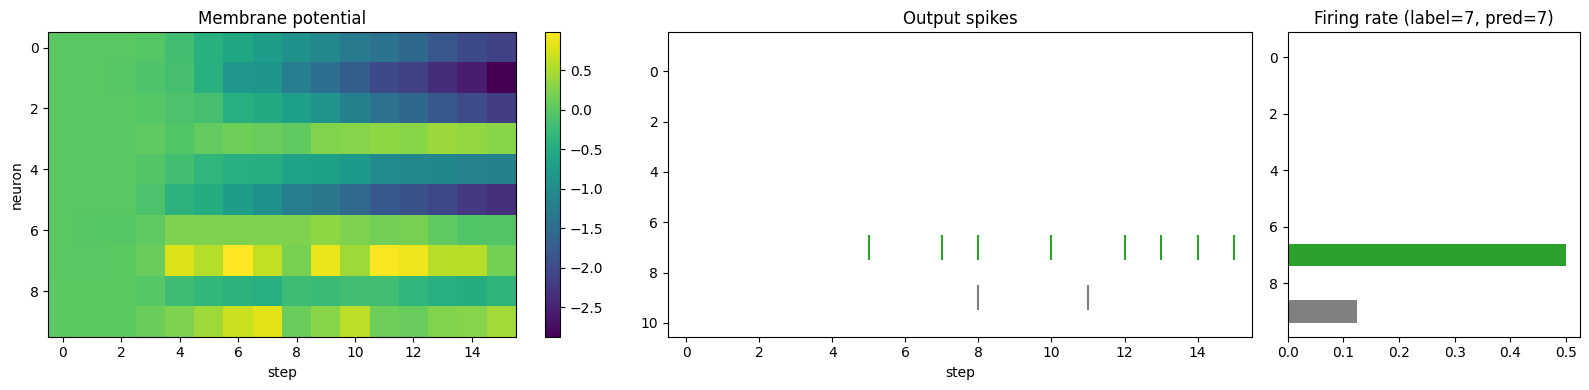

Original label: 7


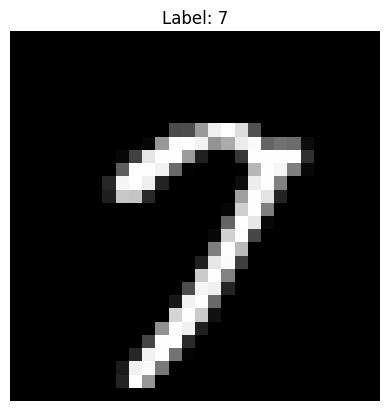

Predicted class (rate coding, T=16): 7


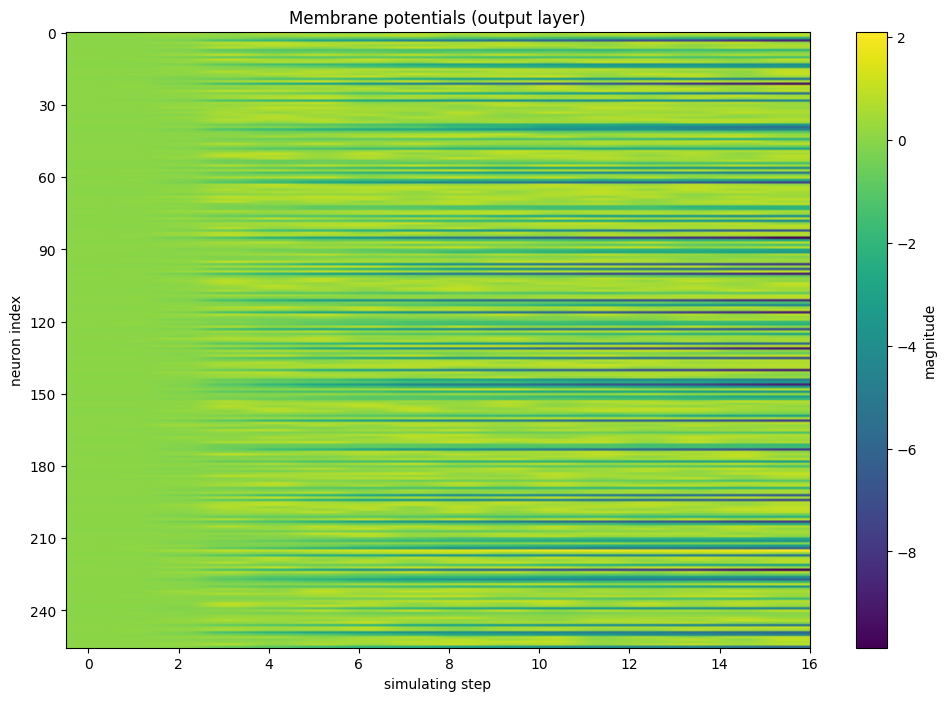

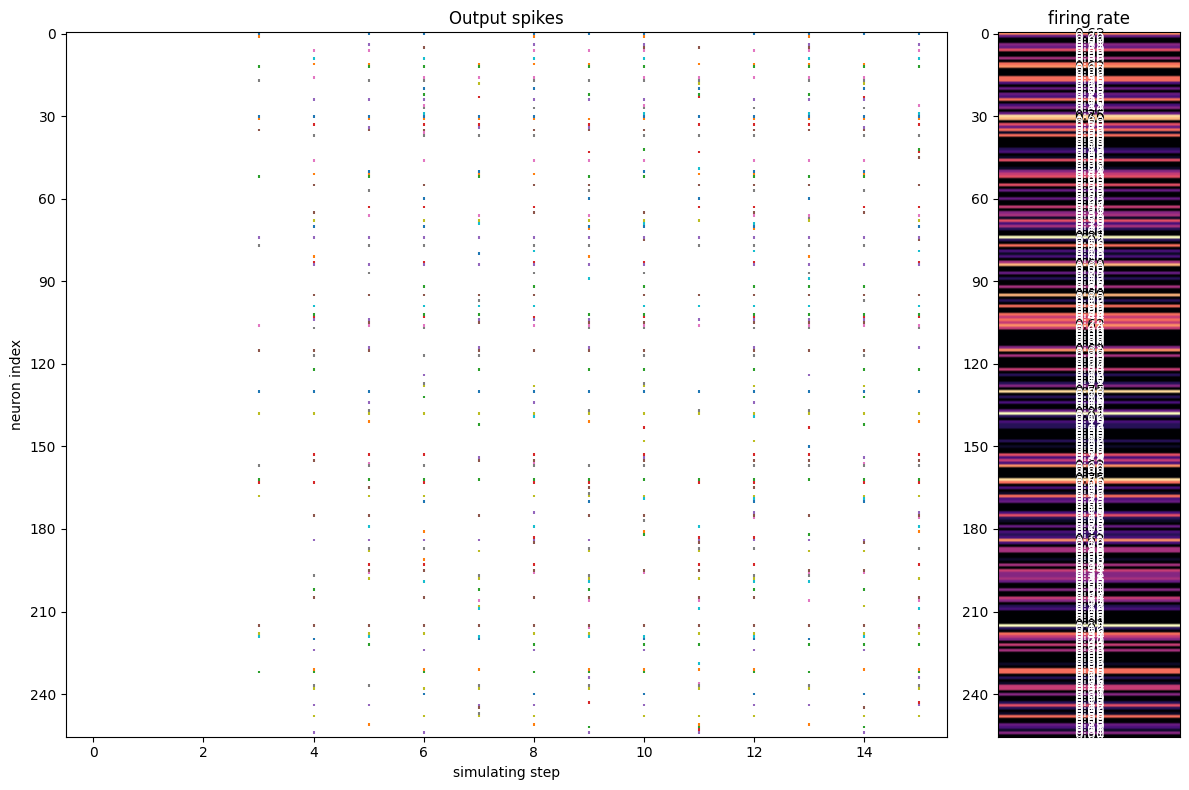

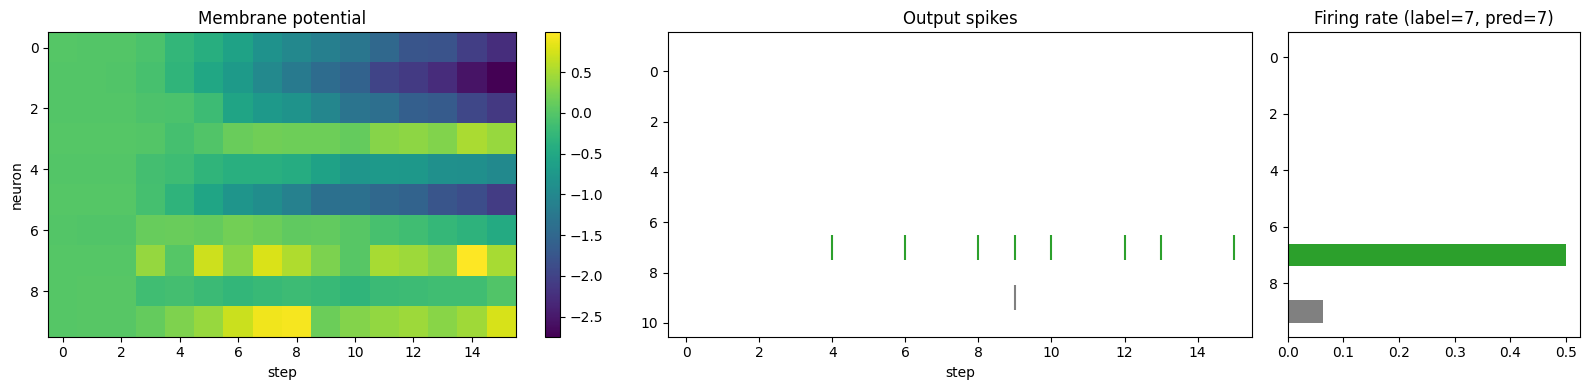

Original label: 7


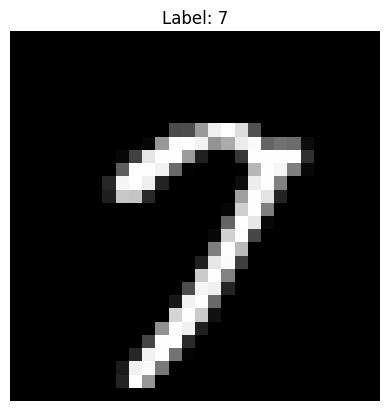

Predicted class (rate coding, T=16): 7


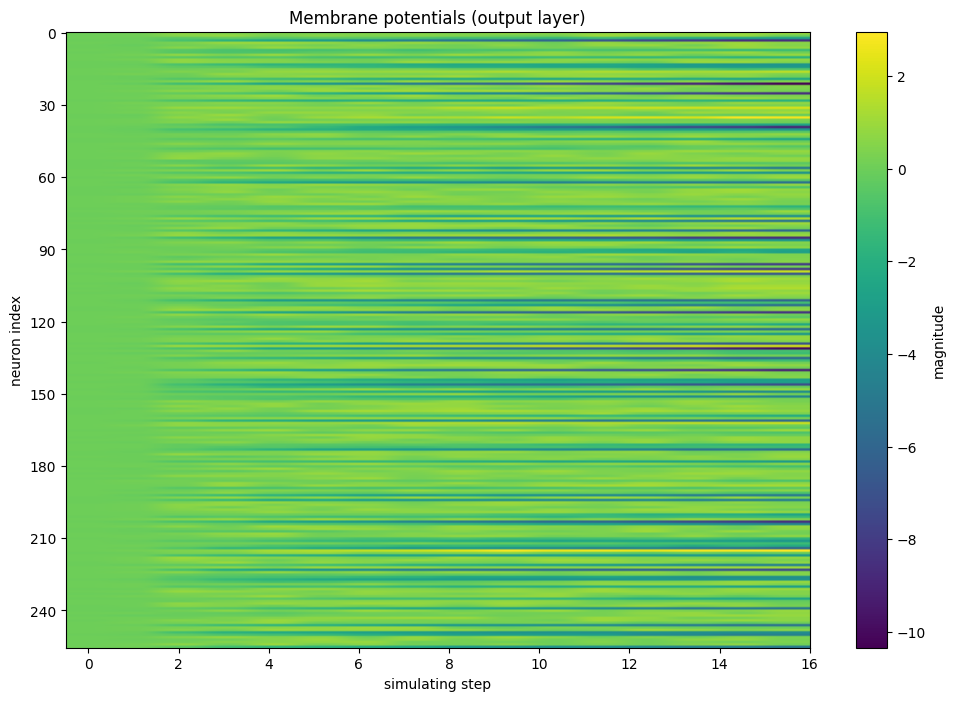

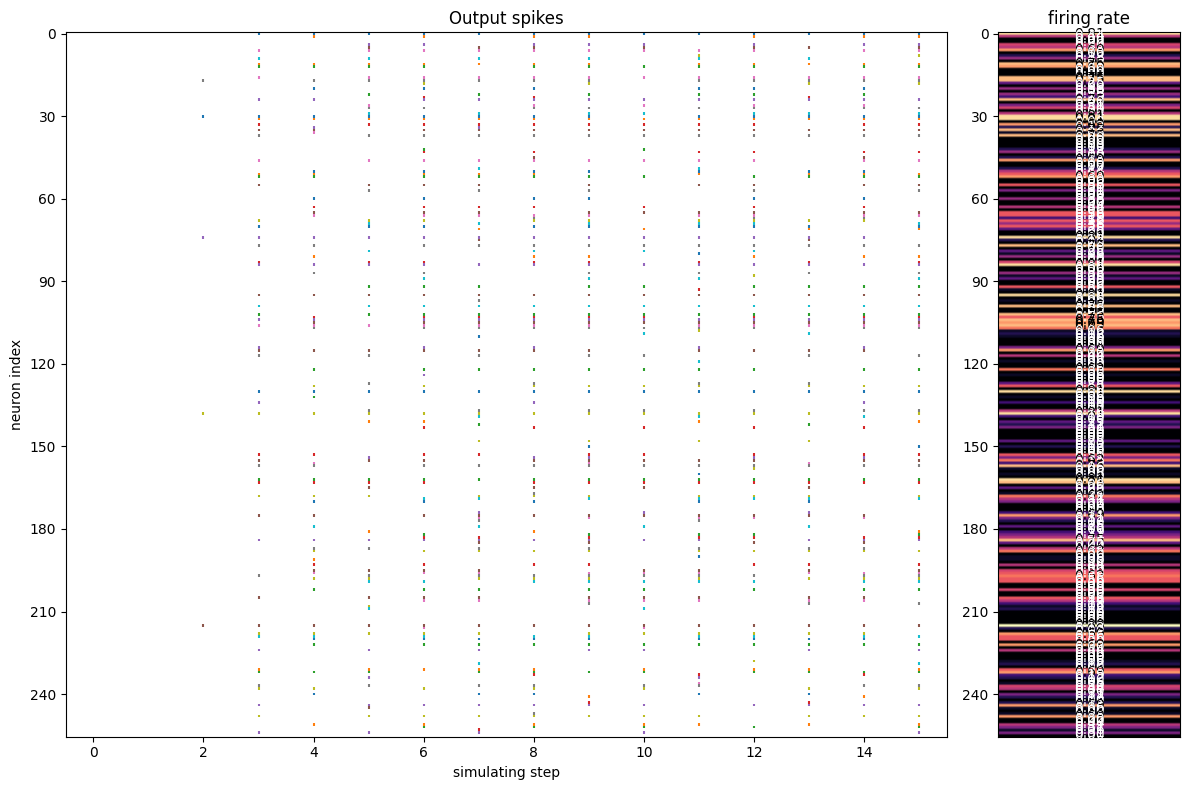

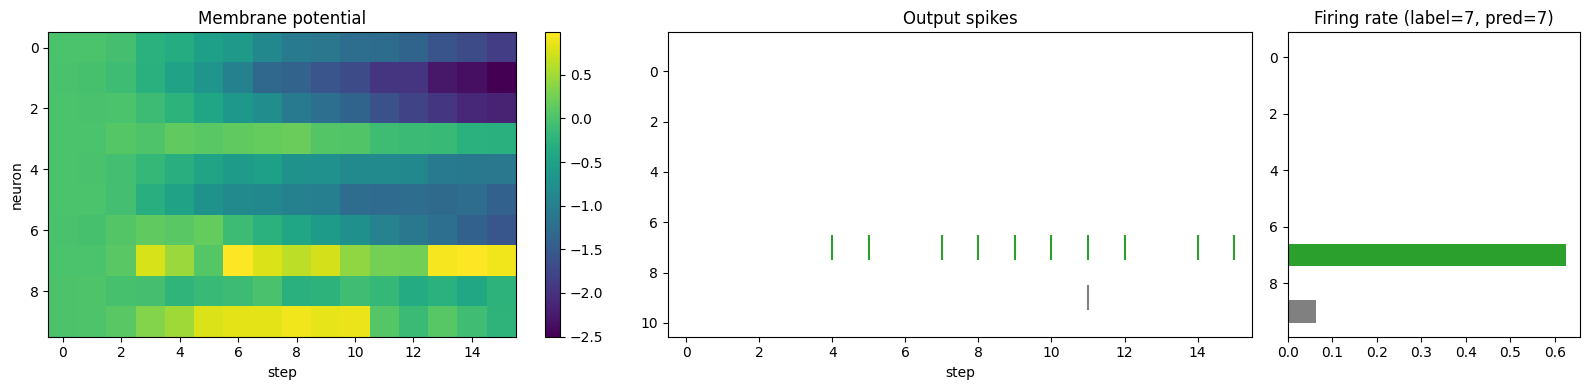

Original label: 7


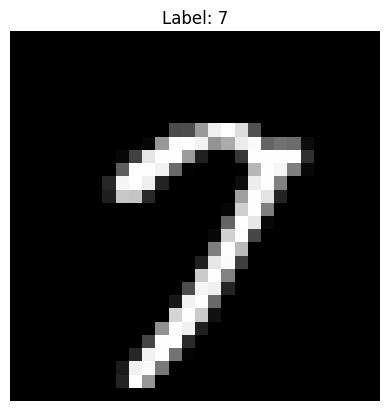

Predicted class (rate coding, T=16): 7


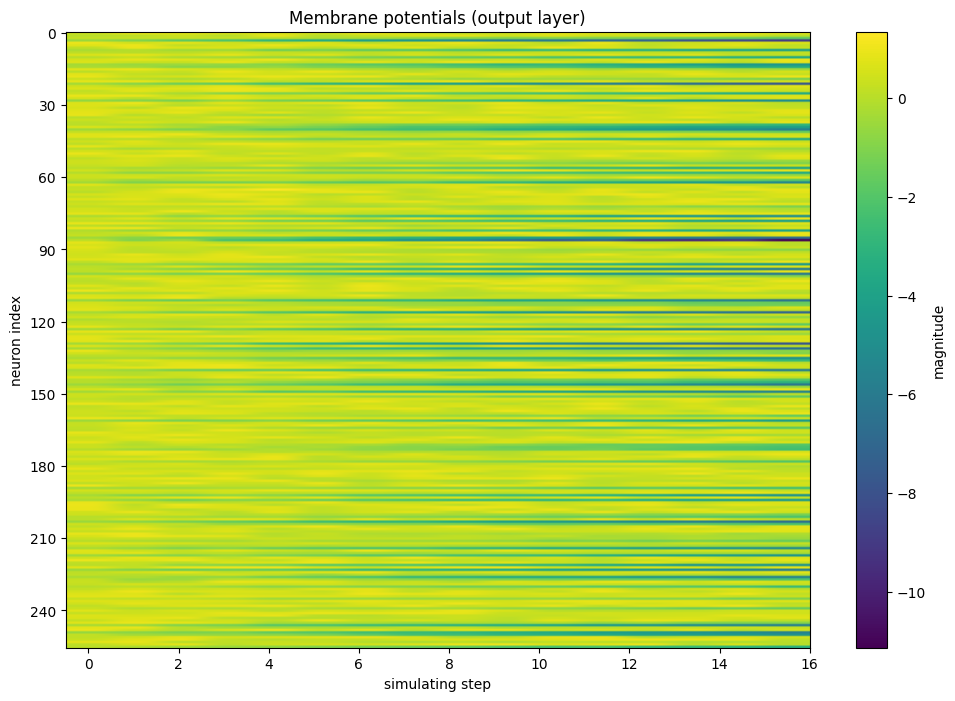

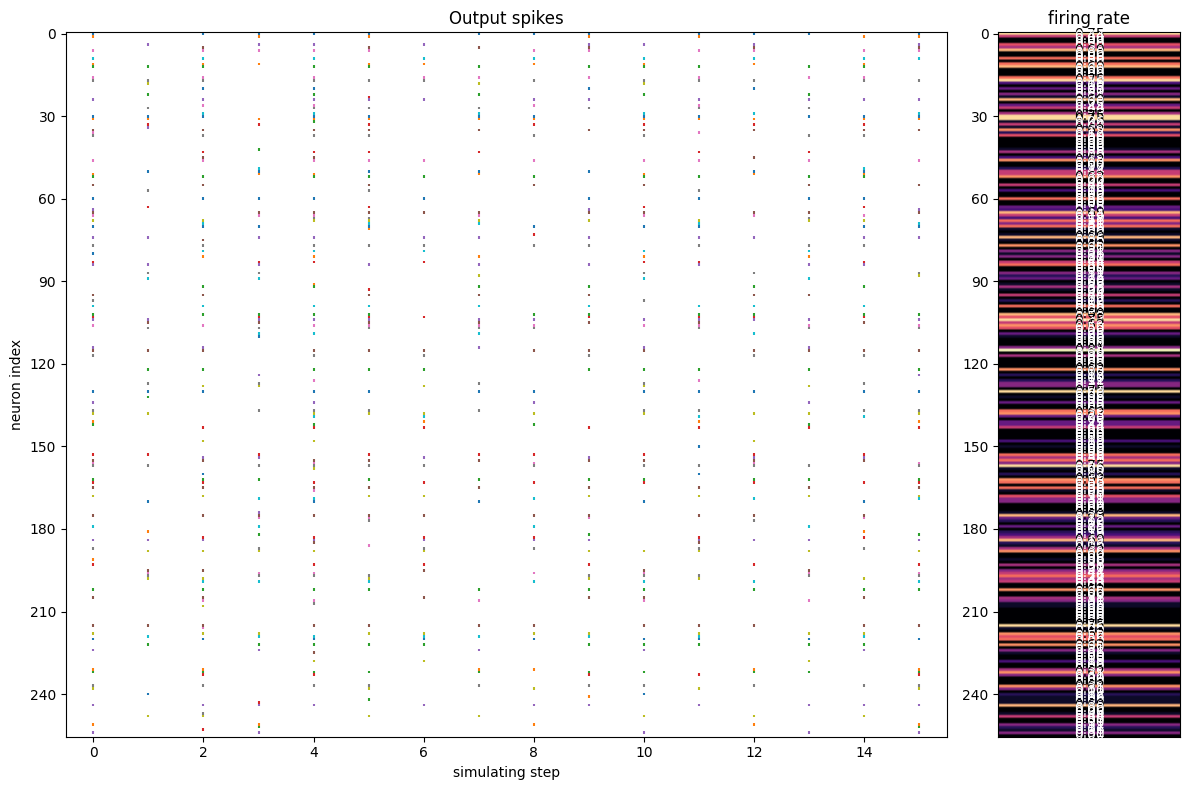

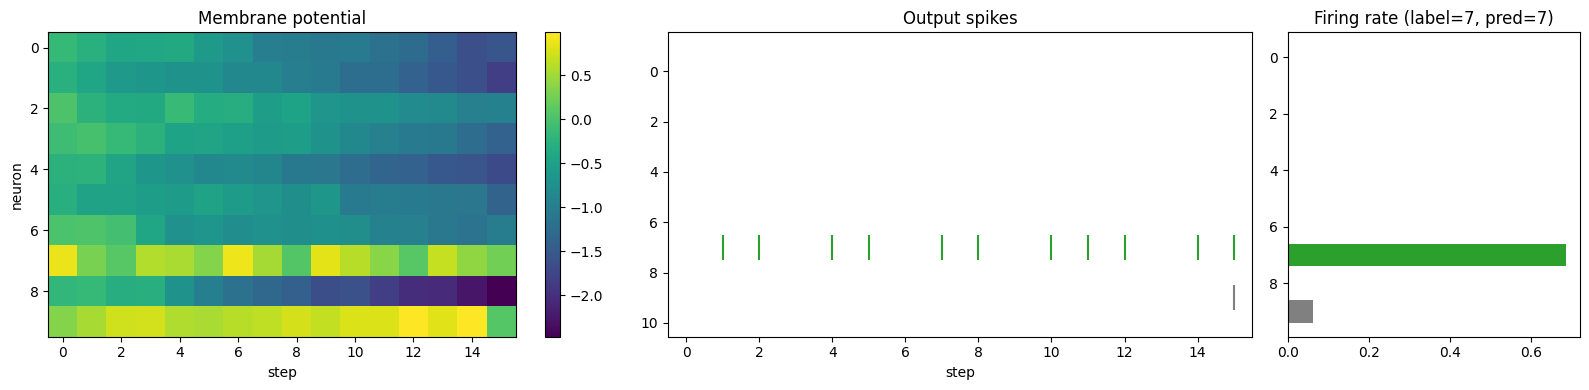

In [102]:
eval_conv_snn.try_visualize_converted(conv_snn_max, test_dataset, T=16, index=3373, device=cfg.device)
eval_conv_snn.try_visualize_converted(conv_snn_99, test_dataset, T=16, index=3373, device=cfg.device)
eval_conv_snn.try_visualize_converted(conv_snn_half, test_dataset, T=16, index=3373, device=cfg.device)
eval_conv_snn.try_visualize_converted(conv_snn_balanced, test_dataset, T=16, index=3373, device=cfg.device)

# Benchmark

In [103]:
from snn_bench.benchmark import Benchmark

In [104]:
import snn_bench.conversion_mod.recipes as snn_bench_recipes

In [105]:
import psutil
import snn_bench.bench.level3 as level3

print("Notebook psutil:", psutil)
print("level3 file:", level3.__file__)
print("level3 has psutil:", hasattr(level3, "psutil"))
print("level3 psutil:", getattr(level3, "psutil", None))


Notebook psutil: <module 'psutil' from '/usr/local/lib/python3.12/dist-packages/psutil/__init__.py'>
level3 file: /usr/local/lib/python3.12/dist-packages/snn_bench/bench/level3.py
level3 has psutil: True
level3 psutil: <module 'psutil' from '/usr/local/lib/python3.12/dist-packages/psutil/__init__.py'>


ANN baseline (int32)
  accuracy        : 0.9830
  MACs            : 5,577,728
  memory ops      : 9,496,916
  E_analytical    : 1.0945e-03 J/sample
    E_mem         : 1.0766e-03 J (98.4%)
    E_ops         : 1.7853e-05 J (1.6%)
    E_addr        : 5.0234e-09 J (0.0%)
  latency         : 0.1605 ms/sample
  GPU (marginal)  : 2.7928e-04 J/sample
  power spread    : 0.3 W across 3 trials

       layer kind     mac      rd    wr      mem_kB  pJ_per_access        E_mem        E_ops      E_total  pct_of_total
  features.0 conv  225792  476672 25088  102.312500      25.670363 1.288036e-05 7.250432e-07 1.360802e-05      1.243330
  features.3 conv 3612672 7237888 12544  145.750000      29.173387 2.115197e-04 1.156180e-05 2.230834e-04     20.382558
classifier.1   fc 1605632 1609280   512 6288.250000     524.536290 8.443943e-04 5.138074e-06 8.495328e-04     77.619629
classifier.4   fc  131072  131840   256  516.000000      59.032258 7.797925e-06 4.194560e-07 8.217458e-06      0.750808
classifier.

Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/util.py", line 303, in _run_finalizers
    finalizer()
  File "/usr/lib/python3.12/multiprocessing/util.py", line 227, in __call__
    res = self._callback(*self._args, **self._kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/util.py", line 136, in _remove_temp_dir
    rmtree(tempdir, onerror=onerror)
  File "/usr/lib/python3.12/shutil.py", line 759, in rmtree
    _rmtree_safe_fd(stack, onexc)
  File "/usr/lib/python3.12/shutil.py", line 703, in _rmtree_safe_fd
    onexc(func, path, err)
  File "/usr/lib/python3.12/shutil.py", line 750, in onexc
    return onerror(func, path, exc_info)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/shutil.py", line 662, in _rmtree_safe_fd
    os.rmdir(name, dir_fd=dirfd)
OSError: [Errno 39] Directory not empty: '/tmp/pymp-rrvib3pb'


  spikes/sample (Total Spikes)    : 74790.0
  spikes/neuron/inf (Spikes per Neuron) : 7.3496 (ABOVE 1.72)
E_ann0.0010944818609951276j => E_snn0.03465471793912903j
  E_ann / E_snn     : 0.032x

--- T = 64 ---
  spikes/sample (Total Spikes)    : 149967.1
  spikes/neuron/inf (Spikes per Neuron) : 14.7373 (ABOVE 1.72)
E_ann0.0010944818609951276j => E_snn0.06930943587825807j
  E_ann / E_snn     : 0.016x
5 synaptic layers, 38410 spiking neurons/sample
  features.0                 conv  ANALOG-IN                neurons=25088   -> features.1
  features.3                 conv  spike-in (x1)            neurons=12544   -> features.4
  classifier.1               fc    spike-in (x1)            neurons=512     -> classifier.2
  classifier.3               fc    spike-in (x1)            neurons=256     -> classifier.4
  classifier.5               fc    spike-in (x1)            neurons=10      -> classifier.6

--- T = 1 ---
  spikes/sample (Total Spikes)    : 917.7
  spikes/neuron/inf (Spikes per Neuro

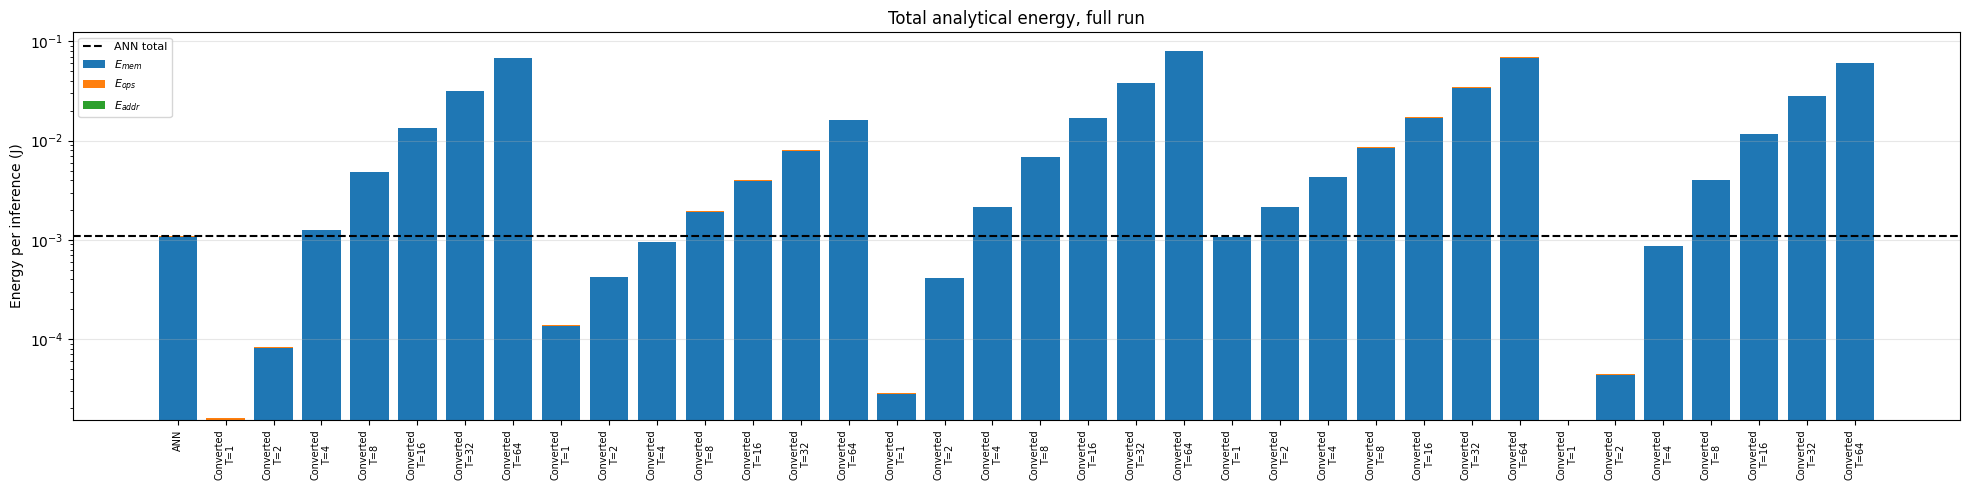

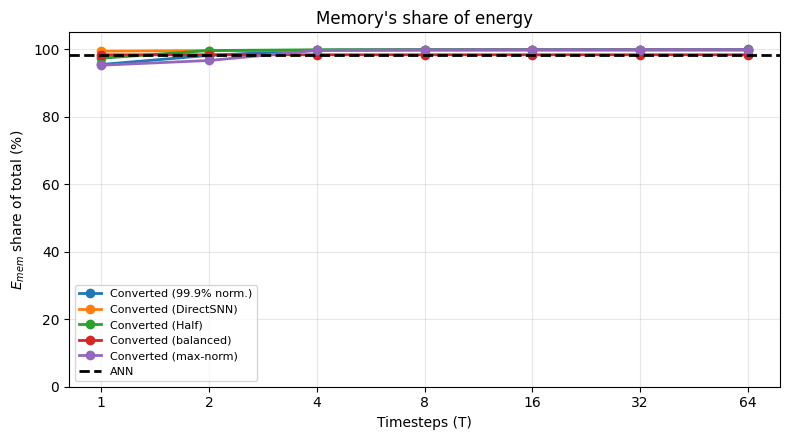

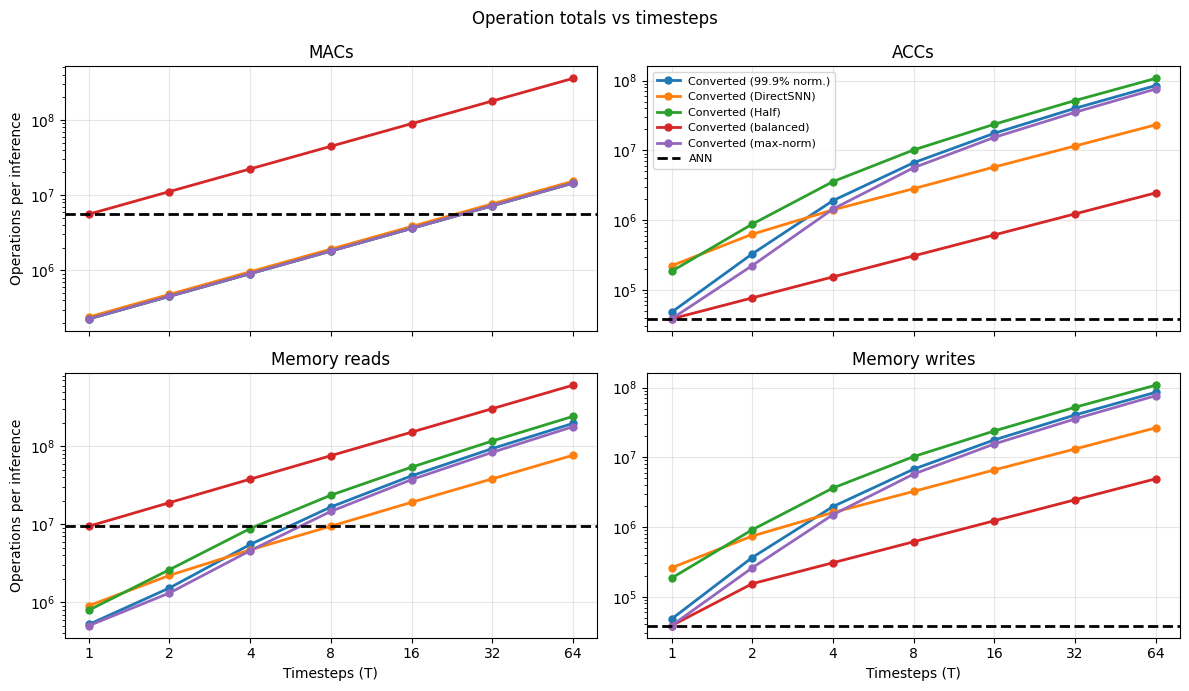

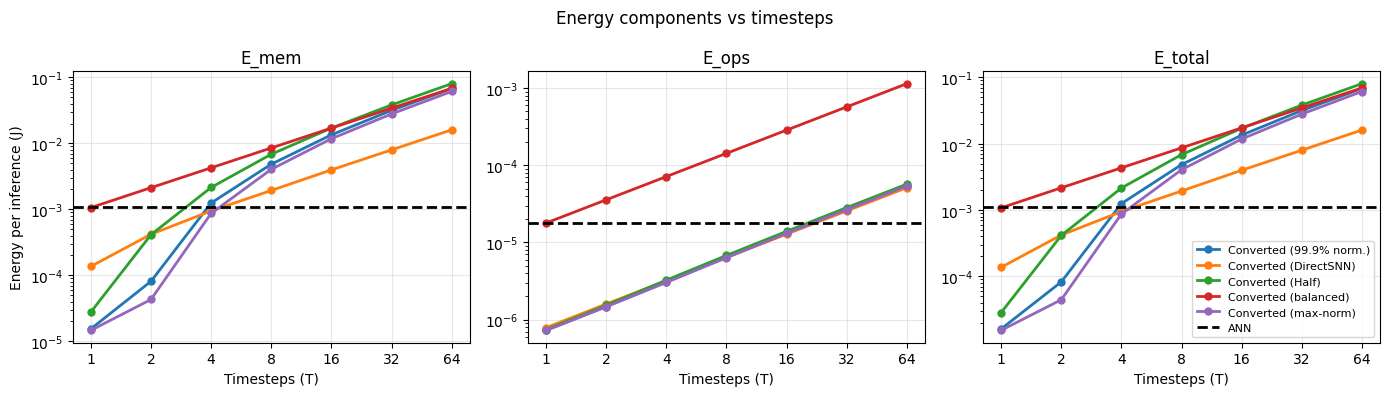

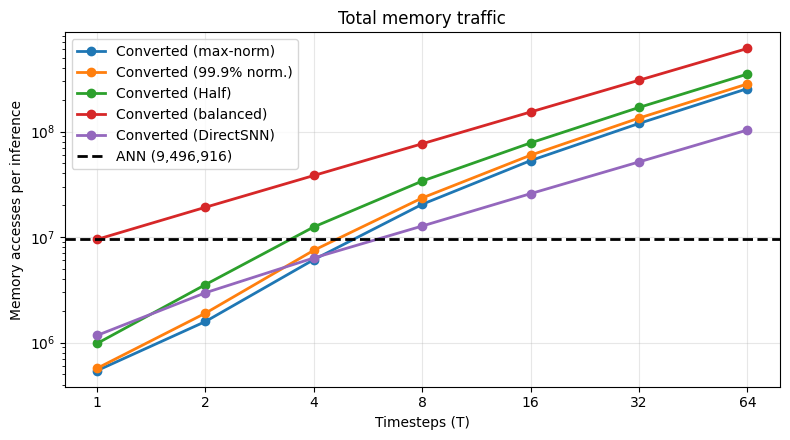

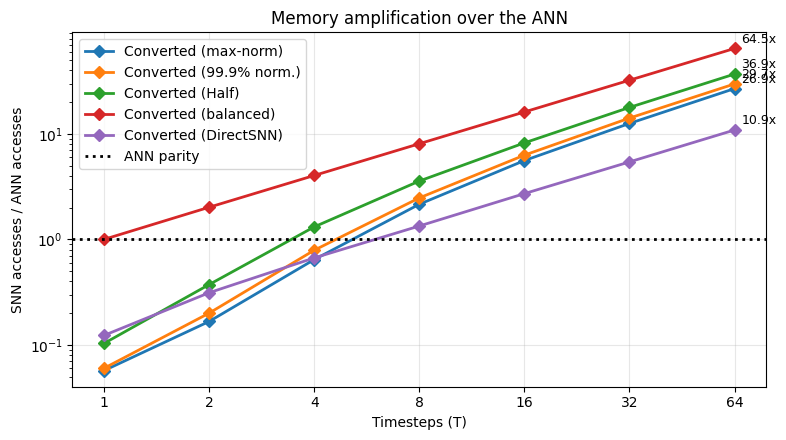

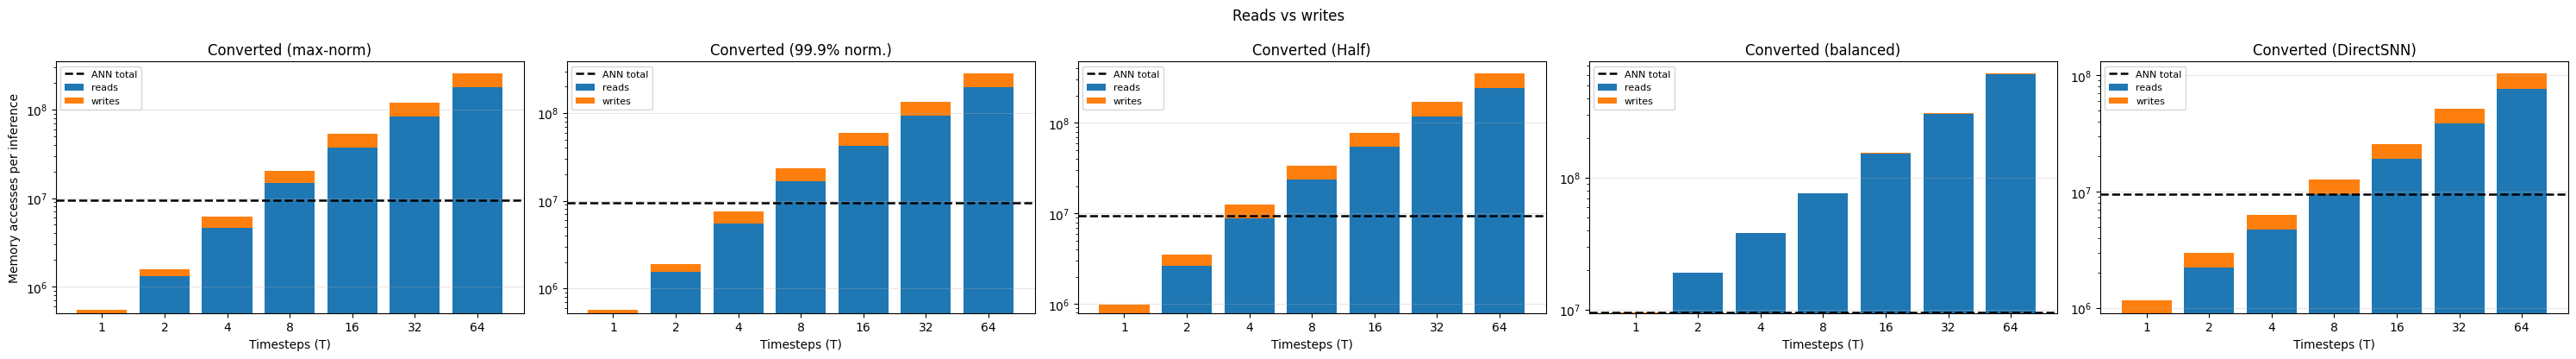

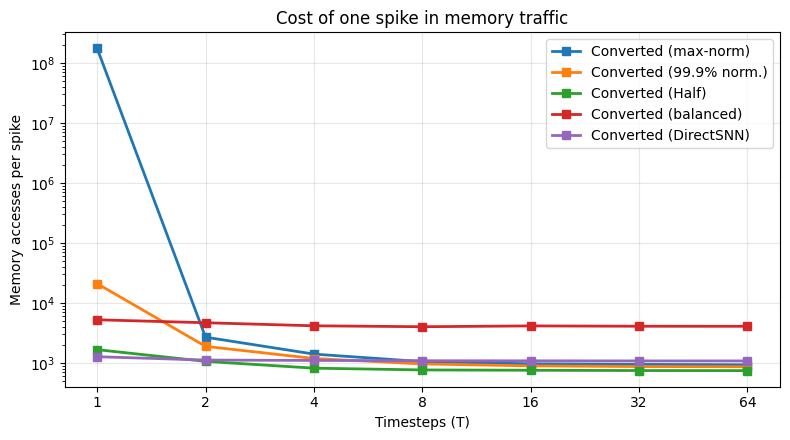

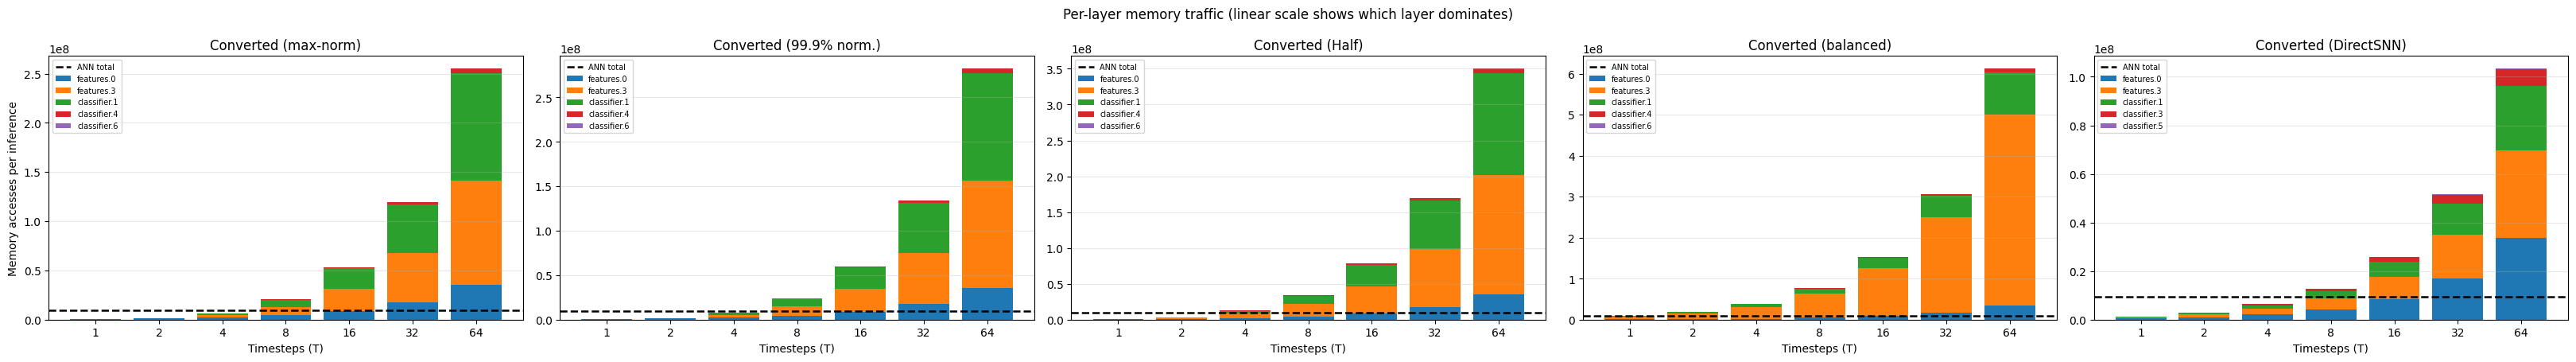

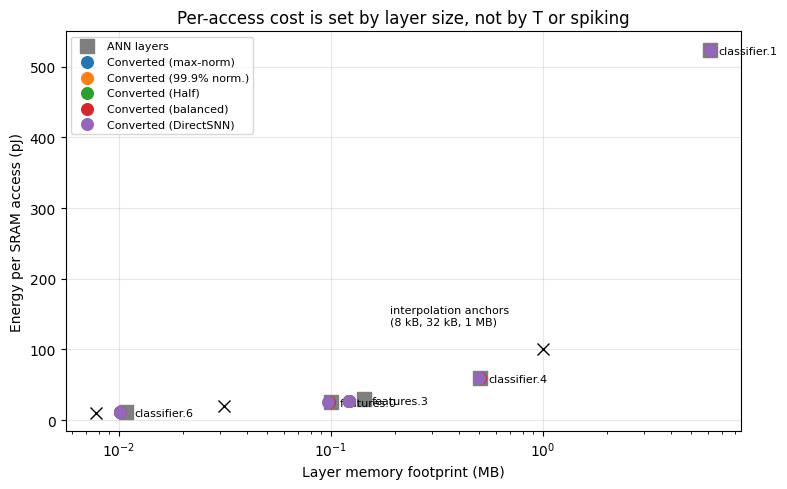

In [106]:
ann_bench_result, totals, snn_models_bench_results = Benchmark.run(ann, {
    "Converted (max-norm)": conv_snn_max,
    "Converted (99.9% norm.)": conv_snn_99,
    "Converted (Half)": conv_snn_half,
    "Converted (balanced)": conv_snn_balanced,
    "Converted (DirectSNN)": snn,
}, test_loader, cfg.device)

In [107]:
ann_bench_result

{'totals': {'E_mem': 0.0010766242669951278,
  'E_ops': 1.78525706e-05,
  'E_addr': 5.023400000000001e-09,
  'E_total': 0.0010944818609951276,
  'mac': 5577728.0,
  'acc': 38410.0,
  'rd': 9458506.0,
  'wr': 38410.0},
 'per_layer':           layer  kind      mac       rd     wr       mem_kB  pJ_per_access  \
 0    features.0  conv   225792   476672  25088   102.312500      25.670363   
 1    features.3  conv  3612672  7237888  12544   145.750000      29.173387   
 2  classifier.1    fc  1605632  1609280    512  6288.250000     524.536290   
 3  classifier.4    fc   131072   131840    256   516.000000      59.032258   
 4  classifier.6    fc     2560     2826     10    11.078125      11.282552   
 
           E_mem         E_ops       E_total  pct_of_total  
 0  1.288036e-05  7.250432e-07  1.360802e-05      1.243330  
 1  2.115197e-04  1.156180e-05  2.230834e-04     20.382558  
 2  8.443943e-04  5.138074e-06  8.495328e-04     77.619629  
 3  7.797925e-06  4.194560e-07  8.217458e-06      

In [108]:
snn_models_bench_results

{'Converted (max-norm)': (    T   total_spikes  total_neurons  spikes_per_neuron  \
  0   1       0.003125          38400       8.138021e-08   
  1   2     587.481250          38400       1.529899e-02   
  2   4    4343.542188          38400       1.131131e-01   
  3   8   19367.007812          38400       5.043492e-01   
  4  16   54701.642578          38400       1.424522e+00   
  5  32  125821.743750          38400       3.276608e+00   
  6  64  273403.766797          38400       7.119890e+00   
  
     spikes_per_neuron_per_step     snn_mac       snn_acc   snn_mem_ops  \
  0                8.138021e-08    225792.0  3.841180e+04  5.417314e+05   
  1                7.649495e-03    451584.0  2.229685e+05  1.582534e+06   
  2                2.827827e-02    903168.0  1.441699e+06  6.110875e+06   
  3                6.304365e-02   1806336.0  5.637667e+06  2.043917e+07   
  4                8.903262e-02   3612672.0  1.534668e+07  5.304289e+07   
  5                1.023940e-01   7225344.0

In [109]:
snn_models_bench_results

{'Converted (max-norm)': (    T   total_spikes  total_neurons  spikes_per_neuron  \
  0   1       0.003125          38400       8.138021e-08   
  1   2     587.481250          38400       1.529899e-02   
  2   4    4343.542188          38400       1.131131e-01   
  3   8   19367.007812          38400       5.043492e-01   
  4  16   54701.642578          38400       1.424522e+00   
  5  32  125821.743750          38400       3.276608e+00   
  6  64  273403.766797          38400       7.119890e+00   
  
     spikes_per_neuron_per_step     snn_mac       snn_acc   snn_mem_ops  \
  0                8.138021e-08    225792.0  3.841180e+04  5.417314e+05   
  1                7.649495e-03    451584.0  2.229685e+05  1.582534e+06   
  2                2.827827e-02    903168.0  1.441699e+06  6.110875e+06   
  3                6.304365e-02   1806336.0  5.637667e+06  2.043917e+07   
  4                8.903262e-02   3612672.0  1.534668e+07  5.304289e+07   
  5                1.023940e-01   7225344.0

In [110]:
from snn_bench.benchmark import BenchLevel 

In [111]:
Benchmark.query_levels(totals, BenchLevel.LEVEL_ONE)


,model,T,accuracy,spikes,neurons,spikes_per_neuron
0,ANN,NaN,0.9830,0.000000,0,NaN
1,Converted (max-norm),1.0,0.1044,0.003125,38400,8.138021e-08
2,Converted (max-norm),2.0,0.1044,587.481250,38400,1.529899e-02
3,Converted (max-norm),4.0,0.4662,4343.542188,38400,1.131131e-01
4,Converted (max-norm),8.0,0.9562,19367.007812,38400,5.043492e-01
5,Converted (max-norm),16.0,0.9306,54701.642578,38400,1.424522e+00
6,Converted (max-norm),32.0,0.9168,125821.743750,38400,3.276608e+00
7,Converted (max-norm),64.0,0.9094,273403.766797,38400,7.119890e+00
8,Converted (99.9% norm.),1.0,0.1044,27.142578,38400,7.068380e-04
9,Converted (99.9% norm.),2.0,0.1044,1002.202344,38400,2.609902e-02


In [112]:
Benchmark.query_levels(totals, BenchLevel.LEVEL_TWO, Ts=[8, 16, 32])


,model,T,accuracy,mac,acc,mem_reads,mem_writes,mem_accesses,accesses_per_mac,accesses_per_spike,mem_amplification,E_mem,E_ops,E_addr,E_total,pct_E_mem,mean_pJ_per_access,E_ratio_ann_over_model
0,ANN,NaN,0.9830,5577728.0,3.841000e+04,9.458506e+06,3.841000e+04,9.496916e+06,1.702650,NaN,1.000000,0.001077,0.000018,5.023400e-09,0.001094,98.368397,113.365672,1.000000
1,Converted (max-norm),8.0,0.9562,1806336.0,5.637667e+06,1.469405e+07,5.745117e+06,2.043917e+07,11.315263,1055.360103,2.152190,0.004045,0.000006,5.850284e-07,0.004052,99.828991,197.901812,0.270117
2,Converted (max-norm),16.0,0.9306,3612672.0,1.534668e+07,3.749464e+07,1.554826e+07,5.304289e+07,14.682455,969.676457,5.585276,0.011760,0.000013,1.595428e-06,0.011775,99.875237,221.709757,0.092951
3,Converted (max-norm),32.0,0.9168,7225344.0,3.510821e+07,8.377964e+07,3.549804e+07,1.192777e+08,16.508236,947.989459,12.559623,0.027923,0.000027,3.648752e-06,0.027954,99.891676,234.104152,0.039153
4,Converted (99.9% norm.),8.0,0.9342,1806336.0,6.651615e+06,1.671901e+07,6.759065e+06,2.347808e+07,12.997625,964.787292,2.472179,0.004833,0.000006,6.919486e-07,0.004840,99.852543,205.858572,0.226119
5,Converted (99.9% norm.),16.0,0.9232,3612672.0,1.756110e+07,4.191605e+07,1.776268e+07,5.967873e+07,16.519277,895.346822,6.284011,0.013469,0.000013,1.829002e-06,0.013484,99.887676,225.687426,0.081170
6,Converted (99.9% norm.),32.0,0.9162,7225344.0,4.004890e+07,9.364479e+07,4.043874e+07,1.340835e+08,18.557390,872.878928,14.118639,0.031618,0.000027,4.170871e-06,0.031650,99.901114,235.810392,0.034581
7,Converted (Half),8.0,0.9442,1806336.0,1.013333e+07,2.367739e+07,1.024078e+07,3.391817e+07,18.777332,766.678273,3.571493,0.006840,0.000007,1.064940e-06,0.006848,99.885245,201.668522,0.159823
8,Converted (Half),16.0,0.9298,3612672.0,2.368197e+07,5.414720e+07,2.388355e+07,7.803075e+07,21.599181,757.212033,8.216431,0.017060,0.000014,2.484198e-06,0.017077,99.903887,218.635742,0.064092
9,Converted (Half),32.0,0.9114,7225344.0,5.175220e+07,1.170308e+08,5.214203e+07,1.691728e+08,23.413805,749.024602,17.813446,0.038196,0.000028,5.425961e-06,0.038230,99.911792,225.783837,0.028629


In [113]:
Benchmark.query_levels(totals, BenchLevel.LEVEL_THREE, models="Converted (max-norm)")


,model,T,accuracy,time_per_sample_ms,gpu_energy_per_sample_J,gpu_energy_marginal_per_sample_J,avg_gpu_power_W,power_spread_W,idle_power_W,gpu_peak_mem_MB,cpu_util_pct,energy_source
0,ANN,NaN,0.9830,0.160457,0.005152,0.000279,32.135714,0.284889,30.393608,137.724609,54.8,nvml_energy_counter
1,Converted (max-norm),1.0,0.1044,0.166388,0.005640,0.000503,33.898177,0.335697,30.876284,173.890625,56.3,nvml_energy_counter
2,Converted (max-norm),2.0,0.1044,0.170245,0.006341,0.000967,37.271374,0.232387,31.590503,180.390625,58.3,nvml_energy_counter
3,Converted (max-norm),4.0,0.4662,0.181207,0.010872,0.005118,60.023610,0.652461,31.767978,180.390625,61.1,nvml_energy_counter
4,Converted (max-norm),8.0,0.9562,0.200481,0.012801,0.006661,63.841680,0.609959,30.623077,180.390625,65.7,nvml_energy_counter
5,Converted (max-norm),16.0,0.9306,0.316026,0.020802,0.011235,65.765217,0.387375,30.245151,180.390625,49.3,nvml_energy_counter
6,Converted (max-norm),32.0,0.9168,0.609336,0.040563,0.022473,66.568676,0.191404,29.687218,180.390625,38.0,nvml_energy_counter
7,Converted (max-norm),64.0,0.9094,1.191143,0.079474,0.043543,66.763352,0.612323,30.184674,180.390625,32.2,nvml_energy_counter


In [114]:
Benchmark.query_levels(totals, [BenchLevel.LEVEL_ONE, BenchLevel.LEVEL_THREE])


,model,T,accuracy,spikes,neurons,spikes_per_neuron,time_per_sample_ms,gpu_energy_per_sample_J,gpu_energy_marginal_per_sample_J,avg_gpu_power_W,power_spread_W,idle_power_W,gpu_peak_mem_MB,cpu_util_pct,energy_source
0,ANN,NaN,0.9830,0.000000,0,NaN,0.160457,0.005152,0.000279,32.135714,0.284889,30.393608,137.724609,54.8,nvml_energy_counter
1,Converted (max-norm),1.0,0.1044,0.003125,38400,8.138021e-08,0.166388,0.005640,0.000503,33.898177,0.335697,30.876284,173.890625,56.3,nvml_energy_counter
2,Converted (max-norm),2.0,0.1044,587.481250,38400,1.529899e-02,0.170245,0.006341,0.000967,37.271374,0.232387,31.590503,180.390625,58.3,nvml_energy_counter
3,Converted (max-norm),4.0,0.4662,4343.542188,38400,1.131131e-01,0.181207,0.010872,0.005118,60.023610,0.652461,31.767978,180.390625,61.1,nvml_energy_counter
4,Converted (max-norm),8.0,0.9562,19367.007812,38400,5.043492e-01,0.200481,0.012801,0.006661,63.841680,0.609959,30.623077,180.390625,65.7,nvml_energy_counter
5,Converted (max-norm),16.0,0.9306,54701.642578,38400,1.424522e+00,0.316026,0.020802,0.011235,65.765217,0.387375,30.245151,180.390625,49.3,nvml_energy_counter
6,Converted (max-norm),32.0,0.9168,125821.743750,38400,3.276608e+00,0.609336,0.040563,0.022473,66.568676,0.191404,29.687218,180.390625,38.0,nvml_energy_counter
7,Converted (max-norm),64.0,0.9094,273403.766797,38400,7.119890e+00,1.191143,0.079474,0.043543,66.763352,0.612323,30.184674,180.390625,32.2,nvml_energy_counter
8,Converted (99.9% norm.),1.0,0.1044,27.142578,38400,7.068380e-04,0.171377,0.005662,0.000459,33.058025,0.193054,30.375761,173.744141,56.8,nvml_energy_counter
9,Converted (99.9% norm.),2.0,0.1044,1002.202344,38400,2.609902e-02,0.175370,0.006475,0.001062,36.965201,0.397055,30.903312,180.244141,58.6,nvml_energy_counter


In [115]:
Benchmark.query_levels(totals, BenchLevel.LEVEL_ALL, include_ann=False)

,model,T,accuracy,spikes,neurons,spikes_per_neuron,mac,acc,mem_reads,mem_writes,...,E_ratio_ann_over_model,time_per_sample_ms,gpu_energy_per_sample_J,gpu_energy_marginal_per_sample_J,avg_gpu_power_W,power_spread_W,idle_power_W,gpu_peak_mem_MB,cpu_util_pct,energy_source
0,Converted (max-norm),1.0,0.1044,0.003125,38400,8.138021e-08,225792.0,3.841180e+04,5.033196e+05,3.841180e+04,...,71.145184,0.166388,0.005640,0.000503,33.898177,0.335697,30.876284,173.890625,56.3,nvml_energy_counter
1,Converted (max-norm),2.0,0.1044,587.481250,38400,1.529899e-02,451584.0,2.229685e+05,1.322712e+06,2.598225e+05,...,24.566516,0.170245,0.006341,0.000967,37.271374,0.232387,31.590503,180.390625,58.3,nvml_energy_counter
2,Converted (max-norm),4.0,0.4662,4343.542188,38400,1.131131e-01,903168.0,1.441699e+06,4.608790e+06,1.502085e+06,...,1.256026,0.181207,0.010872,0.005118,60.023610,0.652461,31.767978,180.390625,61.1,nvml_energy_counter
3,Converted (max-norm),8.0,0.9562,19367.007812,38400,5.043492e-01,1806336.0,5.637667e+06,1.469405e+07,5.745117e+06,...,0.270117,0.200481,0.012801,0.006661,63.841680,0.609959,30.623077,180.390625,65.7,nvml_energy_counter
4,Converted (max-norm),16.0,0.9306,54701.642578,38400,1.424522e+00,3612672.0,1.534668e+07,3.749464e+07,1.554826e+07,...,0.092951,0.316026,0.020802,0.011235,65.765217,0.387375,30.245151,180.390625,49.3,nvml_energy_counter
5,Converted (max-norm),32.0,0.9168,125821.743750,38400,3.276608e+00,7225344.0,3.510821e+07,8.377964e+07,3.549804e+07,...,0.039153,0.609336,0.040563,0.022473,66.568676,0.191404,29.687218,180.390625,38.0,nvml_energy_counter
6,Converted (max-norm),64.0,0.9094,273403.766797,38400,7.119890e+00,14450688.0,7.577238e+07,1.786300e+08,7.653873e+07,...,0.017872,1.191143,0.079474,0.043543,66.763352,0.612323,30.184674,180.390625,32.2,nvml_energy_counter
7,Converted (99.9% norm.),1.0,0.1044,27.142578,38400,7.068380e-04,225792.0,4.785438e+04,5.222211e+05,4.785438e+04,...,67.712480,0.171377,0.005662,0.000459,33.058025,0.193054,30.375761,173.744141,56.8,nvml_energy_counter
8,Converted (99.9% norm.),2.0,0.1044,1002.202344,38400,2.609902e-02,451584.0,3.282638e+05,1.533386e+06,3.651178e+05,...,13.237943,0.175370,0.006475,0.001062,36.965201,0.397055,30.903312,180.244141,58.6,nvml_energy_counter
9,Converted (99.9% norm.),4.0,0.8480,6304.023438,38400,1.641673e-01,903168.0,1.903048e+06,5.530355e+06,1.963434e+06,...,0.874274,0.182717,0.010870,0.005058,59.493164,0.859609,31.813592,180.244141,61.2,nvml_energy_counter


                  model    T  accuracy  baseline_accuracy  retention  retention_pct   delta_pp  delta_rel_pct          label
   Converted (max-norm)  1.0    0.1044              0.983   0.106205      10.620550 -87.859998     -89.379450 0.11x (-89.4%)
   Converted (max-norm)  2.0    0.1044              0.983   0.106205      10.620550 -87.859998     -89.379450 0.11x (-89.4%)
   Converted (max-norm)  4.0    0.4662              0.983   0.474262      47.426247 -51.679998     -52.573753 0.47x (-52.6%)
   Converted (max-norm)  8.0    0.9562              0.983   0.972737      97.273654  -2.679998      -2.726346  0.97x (-2.7%)
   Converted (max-norm) 16.0    0.9306              0.983   0.946694      94.669381  -5.239998      -5.330619  0.95x (-5.3%)
   Converted (max-norm) 32.0    0.9168              0.983   0.932655      93.265516  -6.619998      -6.734484  0.93x (-6.7%)
   Converted (max-norm) 64.0    0.9094              0.983   0.925127      92.512718  -7.359998      -7.487282  0.93x (-7.5%)


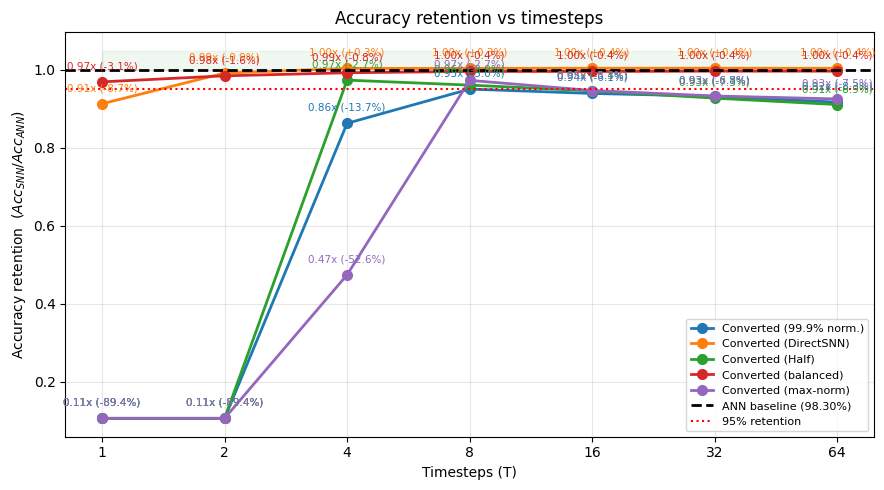

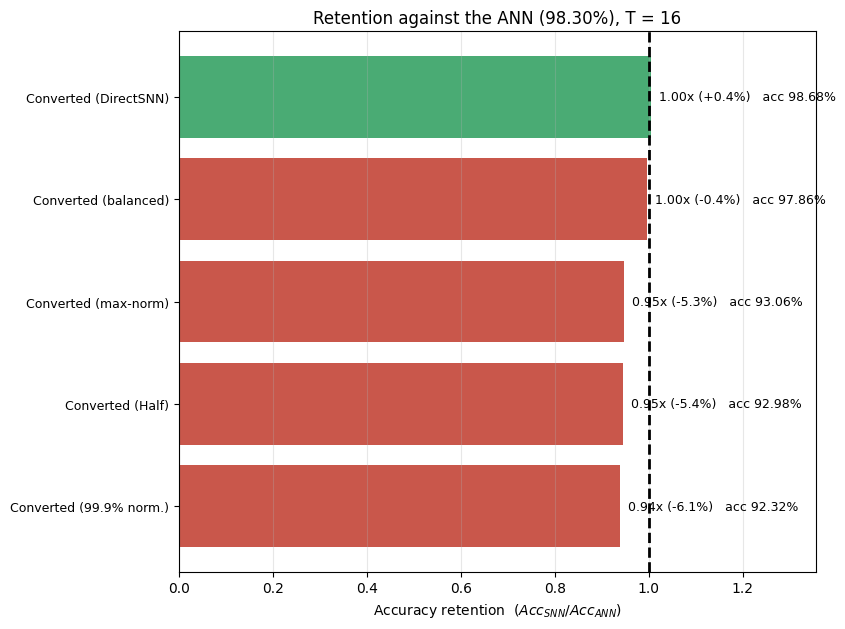

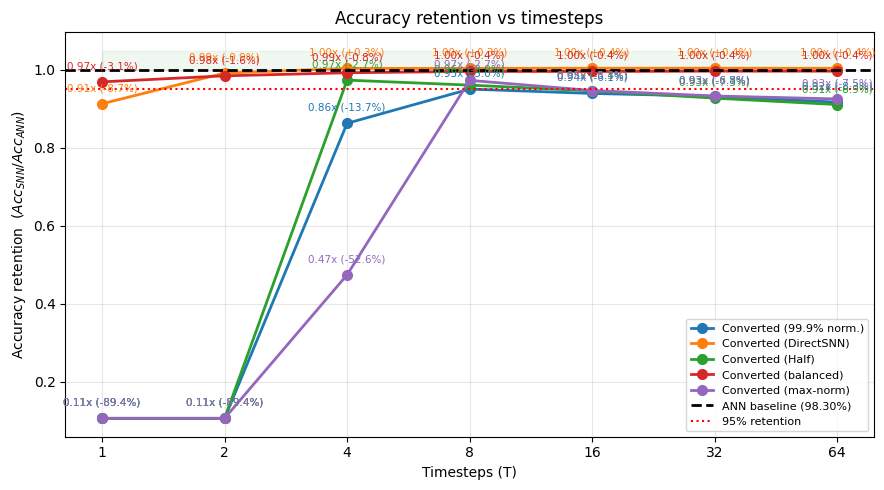

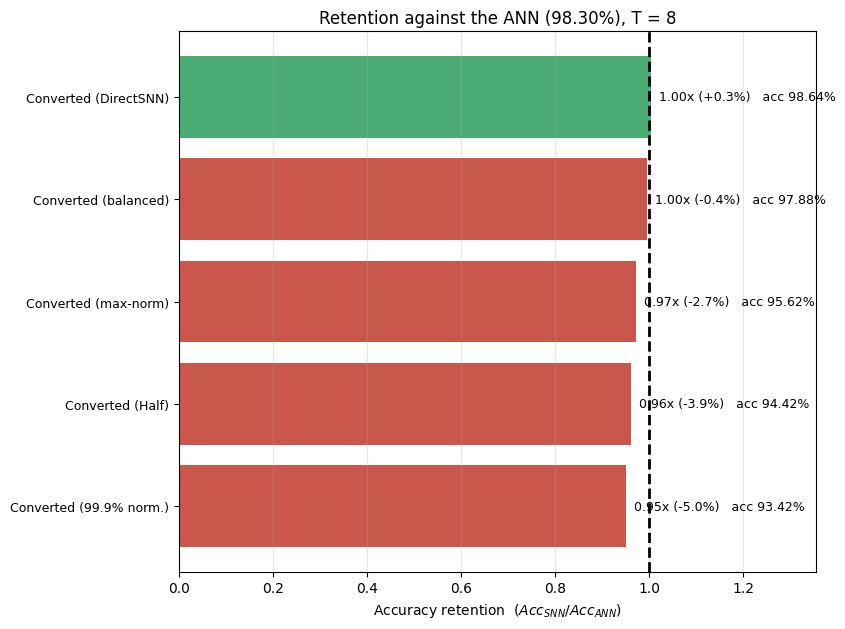

In [116]:
ret = Benchmark.accuracy_retention(
    ann_results['ANN'].accuracy,  # baseline accuracy as a float
    {
        "Converted (max-norm)": conv_snn_max,
        "Converted (99.9% norm.)": conv_snn_99,
        "Converted (Half)": conv_snn_half,
        "Converted (balanced)": conv_snn_balanced,
        "Converted (DirectSNN)": snn,
    },    # the model itself
    loader=test_loader, device=cfg.device,
    Ts=[1, 2, 4, 8, 16, 32, 64],
)

print(ret.to_string(index=False))
print(Benchmark.best_retention(ret).to_string(index=False))

Benchmark.plot_accuracy_retention(ret)                 # picks the best T for the bar chart
Benchmark.plot_accuracy_retention(ret, at_T=8)         # or force one

In [117]:
snn_models_bench_results['Converted (max-norm)'][0]

,T,total_spikes,total_neurons,spikes_per_neuron,spikes_per_neuron_per_step,snn_mac,snn_acc,snn_mem_ops,ann_mac,ann_mem_ops,...,gpu_energy_per_sample_J,gpu_energy_marginal_per_sample_J,avg_gpu_power_W,power_spread_W,energy_source,cpu_util_pct,gpu_peak_mem_MB,accuracy,acc_per_joule_raw,acc_per_joule
0,1,0.003125,38400,8.138021e-08,8.138021e-08,225792.0,3.841180e+04,5.417314e+05,5577728.0,9496916.0,...,0.005640,0.000503,33.898177,0.335697,nvml_energy_counter,56.3,173.890625,0.1044,6786.368440,NaN
1,2,587.481250,38400,1.529899e-02,7.649495e-03,451584.0,2.229685e+05,1.582534e+06,5577728.0,9496916.0,...,0.006341,0.000967,37.271374,0.232387,nvml_energy_counter,58.3,180.390625,0.1044,2343.341073,NaN
2,4,4343.542188,38400,1.131131e-01,2.827827e-02,903168.0,1.441699e+06,6.110875e+06,5577728.0,9496916.0,...,0.010872,0.005118,60.023610,0.652461,nvml_energy_counter,61.1,180.390625,0.4662,535.010456,NaN
3,8,19367.007812,38400,5.043492e-01,6.304365e-02,1806336.0,5.637667e+06,2.043917e+07,5577728.0,9496916.0,...,0.012801,0.006661,63.841680,0.609959,nvml_energy_counter,65.7,180.390625,0.9562,235.989375,211.309457
4,16,54701.642578,38400,1.424522e+00,8.903262e-02,3612672.0,1.534668e+07,5.304289e+07,5577728.0,9496916.0,...,0.020802,0.011235,65.765217,0.387375,nvml_energy_counter,49.3,180.390625,0.9306,79.033069,70.540369
5,32,125821.743750,38400,3.276608e+00,1.023940e-01,7225344.0,3.510821e+07,1.192777e+08,5577728.0,9496916.0,...,0.040563,0.022473,66.568676,0.191404,nvml_energy_counter,38.0,180.390625,0.9168,32.797110,29.219764
6,64,273403.766797,38400,7.119890e+00,1.112483e-01,14450688.0,7.577238e+07,2.551687e+08,5577728.0,9496916.0,...,0.079474,0.043543,66.763352,0.612323,nvml_energy_counter,32.2,180.390625,0.9094,14.849717,13.216803


In [119]:
snn_eff = Benchmark.calculate_energy_efficiency_from_summary(snn_models_bench_results['Converted (max-norm)'][0], n_classes=NUM_CLASSES, min_accuracy=0.5)

In [120]:
snn_eff

,T,accuracy,E_joules,eff_raw,eff_above_chance
0,1,0.1044,0.000015,6786.368440,NaN
1,2,0.1044,0.000045,2343.341073,NaN
2,4,0.4662,0.000871,535.010456,NaN
3,8,0.9562,0.004052,235.989375,211.309457
4,16,0.9306,0.011775,79.033069,70.540369
5,32,0.9168,0.027954,32.797110,29.219764
6,64,0.9094,0.061240,14.849717,13.216803


In [121]:
ann_bench_result

{'totals': {'E_mem': 0.0010766242669951278,
  'E_ops': 1.78525706e-05,
  'E_addr': 5.023400000000001e-09,
  'E_total': 0.0010944818609951276,
  'mac': 5577728.0,
  'acc': 38410.0,
  'rd': 9458506.0,
  'wr': 38410.0},
 'per_layer':           layer  kind      mac       rd     wr       mem_kB  pJ_per_access  \
 0    features.0  conv   225792   476672  25088   102.312500      25.670363   
 1    features.3  conv  3612672  7237888  12544   145.750000      29.173387   
 2  classifier.1    fc  1605632  1609280    512  6288.250000     524.536290   
 3  classifier.4    fc   131072   131840    256   516.000000      59.032258   
 4  classifier.6    fc     2560     2826     10    11.078125      11.282552   
 
           E_mem         E_ops       E_total  pct_of_total  
 0  1.288036e-05  7.250432e-07  1.360802e-05      1.243330  
 1  2.115197e-04  1.156180e-05  2.230834e-04     20.382558  
 2  8.443943e-04  5.138074e-06  8.495328e-04     77.619629  
 3  7.797925e-06  4.194560e-07  8.217458e-06      

In [122]:
ann_eff = Benchmark.calculate_energy_efficiency(ann_bench_result['accuracy'], ann_bench_result['totals']['E_total'])

In [123]:
ann_eff

898.1418834170848

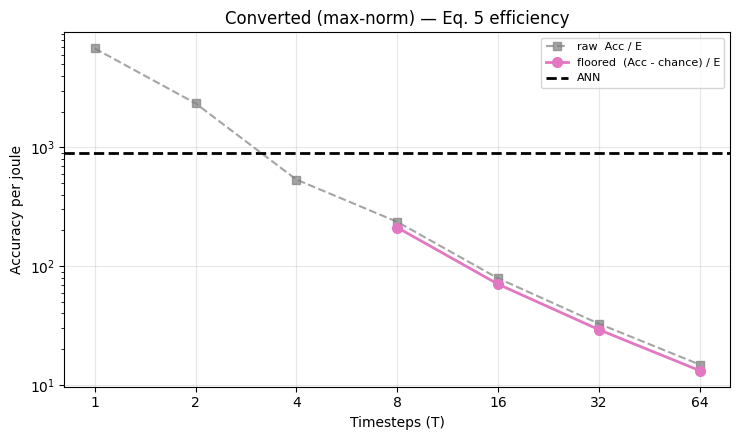

In [124]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (max-norm)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (max-norm) — ")

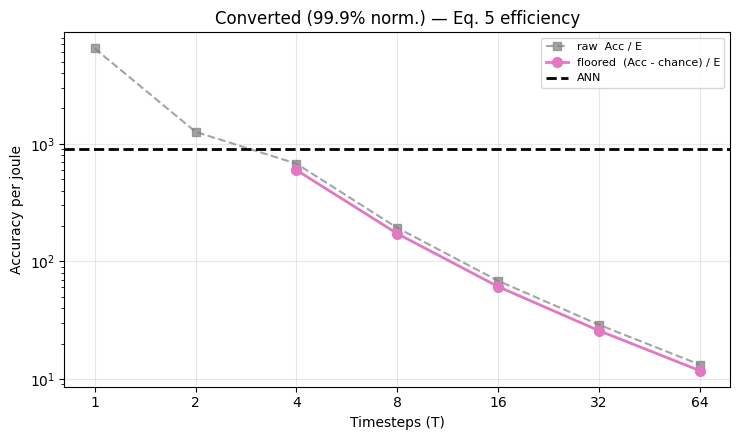

In [125]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (99.9% norm.)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (99.9% norm.) — ")

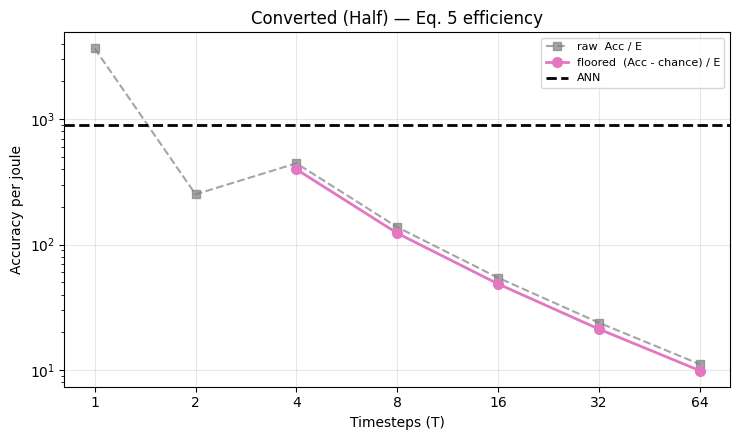

In [126]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (Half)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (Half) — ")

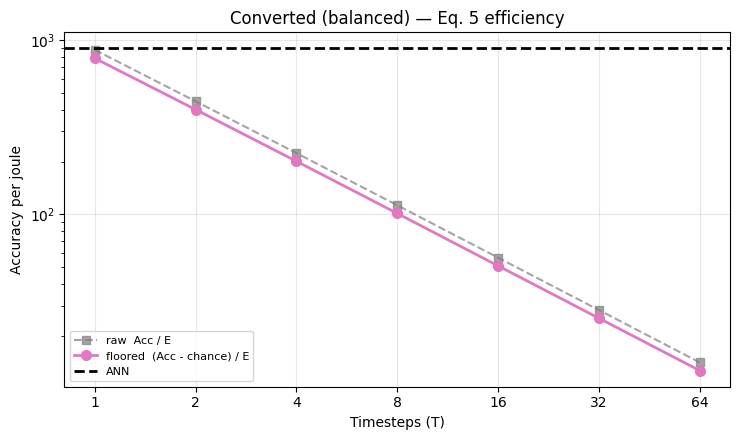

In [127]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (balanced)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (balanced) — ")

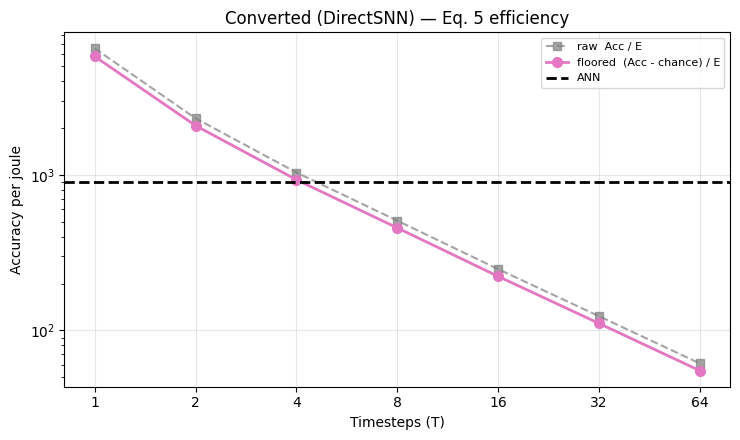

In [128]:
ann_eff_raw = Benchmark.calculate_energy_efficiency(ann_bench_result["accuracy"],ann_bench_result["totals"]["E_total"])

eff = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (DirectSNN)"][0], n_classes=NUM_CLASSES, min_accuracy=0.5
)
Benchmark.plot_energy_efficiency(eff, ann_efficiency=ann_eff, prefix="Converted (DirectSNN) — ")

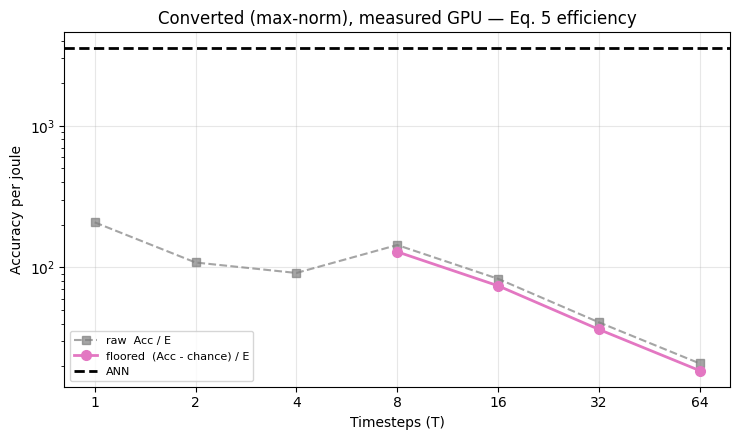

In [130]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (max-norm)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (max-norm), measured GPU — ")

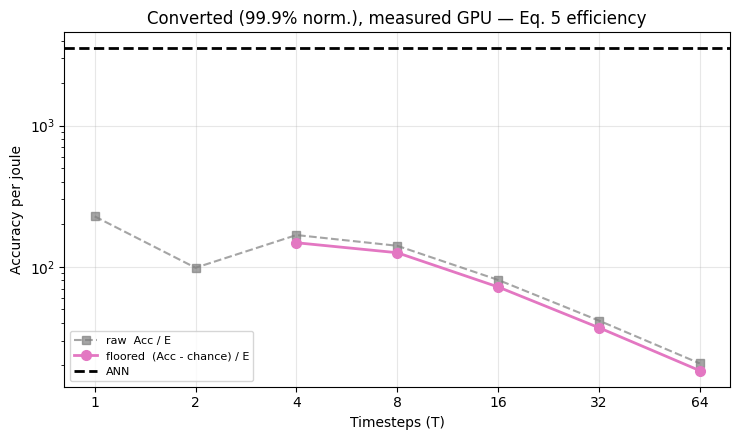

In [131]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (99.9% norm.)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (99.9% norm.), measured GPU — ")

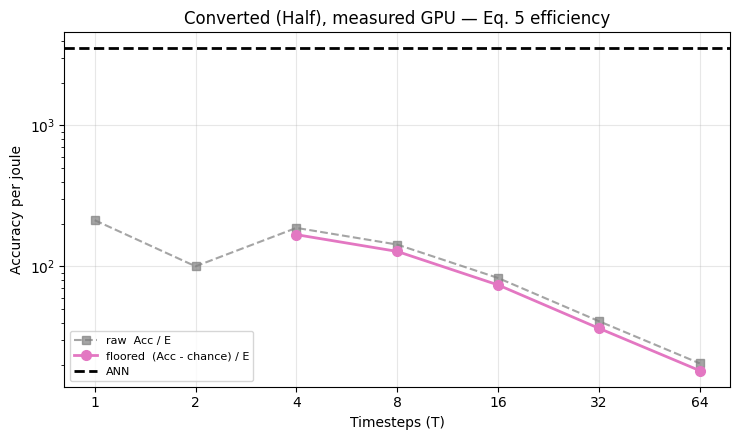

In [132]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (Half)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (Half), measured GPU — ")

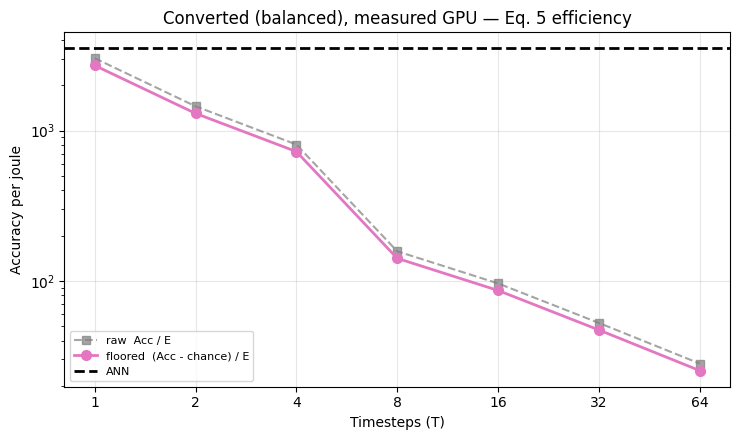

In [133]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (balanced)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (balanced), measured GPU — ")

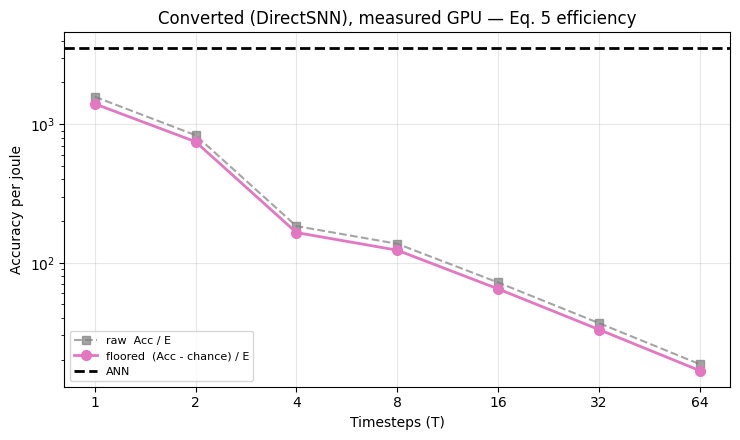

In [134]:
eff_gpu = Benchmark.calculate_energy_efficiency_from_summary(
    snn_models_bench_results["Converted (DirectSNN)"][0], 
    n_classes=NUM_CLASSES, min_accuracy=0.5, 
    energy_col="gpu_energy_marginal_per_sample_J"
)

ann_eff_gpu = Benchmark.calculate_energy_efficiency(
    ann_bench_result["accuracy"],
    ann_bench_result["empirical"]["gpu_energy_marginal_per_sample_J"],
)

Benchmark.plot_energy_efficiency(eff_gpu, ann_eff_gpu, prefix="Converted (DirectSNN), measured GPU — ")

In [145]:
from pathlib import Path
filepath_l1 = Path("results/level_one.csv")
filepath_l2 = Path("results/level_two.csv")
filepath_l3 = Path("results/level_thee.csv")
filepath_l1.parent.mkdir(parents=True, exist_ok=True)
filepath_l2.parent.mkdir(parents=True, exist_ok=True)
filepath_l3.parent.mkdir(parents=True, exist_ok=True)

In [146]:
l1 = Benchmark.query_levels(totals, BenchLevel.LEVEL_ONE)
l1.to_csv(filepath_l1)

In [147]:
l2 = Benchmark.query_levels(totals, BenchLevel.LEVEL_TWO)
l2.to_csv(filepath_l2)

In [148]:
l3 = Benchmark.query_levels(totals, BenchLevel.LEVEL_THREE)
l3.to_csv(filepath_l3)